# Combs-Weschler Stock Research & Analysis Tool

A dual-lens quantitative screening system encoding the investment philosophies of **Todd Combs** and **Ted Weschler** to identify undervalued S&P 500 companies.

- **Combs Lens**: Strong unit economics, moats, frictionless operations, capital allocation
- **Weschler Lens**: Mispriced, complex, or misunderstood situations with quality underneath

In [1]:
# ============================================================
# Cell 1 — Dependencies & Configuration
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
import os, pickle, time
from datetime import datetime, timedelta
from IPython.display import display, HTML

DATA_DIR = '/Users/brendonmuur/Desktop/data'
OUTPUT_DIR = '/Users/brendonmuur/Desktop/output'
CACHE_FILE = os.path.join(DATA_DIR, 'sp500_cache.pkl')
WATCHLIST_FILE = os.path.join(OUTPUT_DIR, 'watchlist.csv')
DEEP_DIVE_DIR = os.path.join(OUTPUT_DIR, 'deep_dives')

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(DEEP_DIVE_DIR, exist_ok=True)

COMBS_WEIGHTS = {
    'unit_economics': 0.25,
    'frictionless_ops': 0.25,
    'capital_allocation': 0.25,
    'moat_strength': 0.25,
}
WESCHLER_WEIGHTS = {
    'variant_perception': 0.20,
    'complexity_discount': 0.20,
    'distressed_value': 0.20,
    'business_quality': 0.20,
    'long_term_compounding': 0.20,
}

END_DATE = datetime.today()
START_DATE_5Y = END_DATE - timedelta(days=5*365)
START_DATE_3Y = END_DATE - timedelta(days=3*365)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print('✅ Configuration loaded')
print(f'   Data directory: {DATA_DIR}')
print(f'   Output directory: {OUTPUT_DIR}')
print(f'   Analysis window: {START_DATE_5Y.strftime("%Y-%m-%d")} to {END_DATE.strftime("%Y-%m-%d")}')

✅ Configuration loaded
   Data directory: /Users/brendonmuur/Desktop/data
   Output directory: /Users/brendonmuur/Desktop/output
   Analysis window: 2021-04-12 to 2026-04-11


In [2]:
# ============================================================
# Cell 2 — S&P 500 Ticker List & Data Collection
# ============================================================

def get_sp500_tickers():
    """Get S&P 500 constituents. Tries saved CSV, then Wikipedia, then hardcoded fallback."""
    csv_path = os.path.join(DATA_DIR, 'sp500_full_list.csv')
    
    # Try saved CSV first (from Wikipedia fetch)
    if os.path.exists(csv_path):
        tdf = pd.read_csv(csv_path)
        print(f'📋 Loaded S&P 500 list from {csv_path}')
        return tdf
    
    # Try Wikipedia with proper headers
    try:
        import requests, io
        headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36'}
        resp = requests.get('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies', headers=headers)
        if resp.status_code == 200:
            tables = pd.read_html(io.StringIO(resp.text))
            tdf = tables[0]
            tdf['Symbol'] = tdf['Symbol'].str.replace('.', '-', regex=False)
            result = tdf[['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry']].copy()
            result.to_csv(csv_path, index=False)
            print(f'📋 Fetched S&P 500 from Wikipedia and saved to {csv_path}')
            return result
    except Exception as e:
        print(f'⚠️  Wikipedia fetch failed ({e.__class__.__name__}), using hardcoded list')

    sp500_data = {
        'Information Technology': ['AAPL','MSFT','NVDA','AVGO','ORCL','CRM','AMD','CSCO','ACN','ADBE','IBM','INTC','QCOM','TXN','INTU','AMAT','NOW','ADI','LRCX','MU','KLAC','SNPS','CDNS','APH','MCHP','TEL','FTNT','MSI','IT','KEYS','ON','ANSS','CDW','FSLR','TDY','TRMB','PTC','ZBRA','NDSN','GEN','SWKS','TER','JNPR','FFIV','EPAM','AKAM','ENPH','CTSH','HPQ','HPE','GLW','WDC','STX','NTAP','MPWR','VRSN','ROP','PAYC','FICO','GDDY','TYL','MANH','BEN'],
        'Health Care': ['UNH','LLY','JNJ','ABBV','MRK','TMO','ABT','DHR','PFE','AMGN','ISRG','MDT','ELV','BSX','GILD','VRTX','SYK','BMY','CI','REGN','ZTS','BDX','HCA','IDXX','EW','MTD','IQV','A','DXCM','BAX','HOLX','ALGN','PODD','TECH','HSIC','CRL','INCY','BIIB','MOH','HUM','CNC','RMD','COO','WAT','STE','DGX','LH','VTRS','OGN','DVA','CAH','MCK','ABC','WBA','CVS'],
        'Financials': ['BRK-B','JPM','V','MA','BAC','WFC','GS','MS','SPGI','BLK','AXP','C','SCHW','CB','MMC','PGR','AON','ICE','CME','MCO','MSCI','AIG','MET','AFL','TRV','ALL','PRU','AJG','BK','STT','TROW','NTRS','WRB','FDS','CBOE','RJF','CINF','HBAN','RF','CFG','KEY','MTB','FITB','USB','PNC','TFC','ZION','CMA','GL','RE','L','BRO','FIS','FISV','PYPL','COF','DFS','SYF','AMP','IVZ','NDAQ'],
        'Consumer Discretionary': ['AMZN','TSLA','HD','MCD','NKE','LOW','SBUX','TJX','BKNG','ABNB','ORLY','CMG','MAR','DHI','YUM','LEN','GM','F','ROST','EBAY','APTV','GRMN','POOL','PHM','NVR','DRI','WYNN','LVS','CZR','MGM','HLT','RCL','CCL','NCLH','DPZ','BBY','ULTA','AZO','KMX','GPC','ETSY','DECK','LULU','HAS','EXPE','LKQ','BWA','RL','TPR','CPRI','WHR','MHK','PVH'],
        'Communication Services': ['META','GOOGL','GOOG','DIS','NFLX','CMCSA','T','VZ','TMUS','CHTR','EA','TTWO','MTCH','WBD','PARA','LYV','OMC','IPG','FOXA','FOX','NWS','NWSA'],
        'Industrials': ['GE','CAT','UNP','RTX','HON','DE','UPS','BA','LMT','ADP','ETN','ITW','EMR','GD','MMM','NSC','CSX','WM','RSG','PCAR','TT','CTAS','FAST','VRSK','CPRT','ODFL','GWW','ROK','DOV','AME','SWK','FTV','IR','PWR','HUBB','WAB','EFX','BR','LDOS','J','TDG','IEX','PNR','AOS','ALLE','HWM','AXON','XYL','SNA','GNRC','RHI','MAS','JBHT','CHRW','DAL','LUV','UAL','AAL'],
        'Consumer Staples': ['PG','KO','PEP','COST','WMT','PM','MO','MDLZ','CL','KMB','GIS','K','SJM','CAG','CPB','HRL','HSY','MKC','CHD','CLX','EL','STZ','BF-B','TAP','SAM','KHC','KR','SYY','ADM','BG','TSN','MNST','KDP'],
        'Energy': ['XOM','CVX','COP','SLB','EOG','MPC','PSX','VLO','PXD','OXY','HES','DVN','WMB','KMI','OKE','CTRA','HAL','BKR','FANG','TRGP','MRO','APA','EQT'],
        'Utilities': ['NEE','DUK','SO','D','SRE','AEP','EXC','XEL','WEC','ED','DTE','ES','FE','PPL','AEE','CMS','CNP','AWK','EVRG','ATO','NI','PNW','NRG','CEG','VST'],
        'Real Estate': ['PLD','AMT','CCI','EQIX','PSA','SPG','O','DLR','WELL','AVB','EQR','VICI','VTR','ARE','MAA','ESS','UDR','REG','KIM','CPT','HST','PEAK','BXP','SLG','FRT','CBRE','IRM','SBAC','WY','INVH'],
        'Materials': ['LIN','APD','SHW','ECL','FCX','NUE','VMC','MLM','DD','DOW','CE','PPG','NEM','CF','MOS','ALB','FMC','IFF','CTVA','EMN','IP','PKG','SEE','AVY','BALL','AMCR','WRK']
    }
    rows = []
    for sector, tickers in sp500_data.items():
        for t in tickers:
            rows.append({'Symbol': t, 'Security': t, 'GICS Sector': sector, 'GICS Sub-Industry': sector})
    return pd.DataFrame(rows)

def fetch_ticker_data(ticker, retries=2):
    for attempt in range(retries):
        try:
            t = yf.Ticker(ticker)
            return {'info': t.info or {}, 'financials': t.financials, 'balance_sheet': t.balance_sheet, 'cashflow': t.cashflow, 'history': t.history(period='5y', interval='1mo')}
        except Exception:
            if attempt < retries - 1: time.sleep(1)
            else: return None
    return None

def collect_all_data(tickers_df, use_cache=True):
    if use_cache and os.path.exists(CACHE_FILE):
        if (time.time() - os.path.getmtime(CACHE_FILE)) < 86400:
            print('📦 Loading cached data...')
            with open(CACHE_FILE, 'rb') as f:
                data = pickle.load(f)
            print(f'   Cache loaded: {len(data)} tickers')
            return data

    all_data, failed = {}, []
    symbols = tickers_df['Symbol'].tolist()
    total = len(symbols)
    print(f'📡 Fetching data for {total} tickers...')
    for i, ticker in enumerate(symbols):
        if (i + 1) % 25 == 0 or i == 0:
            print(f'   Progress: {i+1}/{total} ({100*(i+1)/total:.0f}%)')
        data = fetch_ticker_data(ticker)
        if data: all_data[ticker] = data
        else: failed.append(ticker)
        if (i + 1) % 50 == 0: time.sleep(2)
    print(f'\n✅ Successfully fetched: {len(all_data)}/{total}')
    if failed: print(f'⚠️  Failed ({len(failed)}): {failed}')
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(all_data, f)
    print(f'💾 Data cached to {CACHE_FILE}')
    return all_data

sp500_df = get_sp500_tickers()
print(f'📋 S&P 500 constituents: {len(sp500_df)} companies, {sp500_df["GICS Sector"].nunique()} sectors')
raw_data = collect_all_data(sp500_df)

📋 Loaded S&P 500 list from /Users/brendonmuur/Desktop/data/sp500_full_list.csv
📋 S&P 500 constituents: 503 companies, 11 sectors
📦 Loading cached data...
   Cache loaded: 503 tickers


In [3]:
# ============================================================
# Cell 3 — Data Cleaning & Derived Metrics
# ============================================================

def safe_get(info, key, default=np.nan):
    val = info.get(key, default)
    return np.nan if val is None or val in ('Infinity', '-Infinity') else val

def calc_cagr(series, years):
    if series is None or len(series) < 2: return np.nan
    first, last = series.iloc[-1], series.iloc[0]
    if first <= 0 or last <= 0: return np.nan
    return (last / first) ** (1 / years) - 1

def safe_div(num, denom):
    if pd.isna(num) or pd.isna(denom) or denom == 0: return np.nan
    return num / denom

sector_map = dict(zip(sp500_df['Symbol'], sp500_df['GICS Sector']))

metrics_list = []
for ticker, data in raw_data.items():
    try:
        info = data.get('info', {})
        fin, bs, cf, hist = data.get('financials'), data.get('balance_sheet'), data.get('cashflow'), data.get('history')
        m = {'ticker': ticker, 'company': safe_get(info,'longName',ticker), 'sector': sector_map.get(ticker, safe_get(info,'sector','Unknown')),
             'market_cap': safe_get(info,'marketCap'), 'description': safe_get(info,'longBusinessSummary',''),
             'trailing_pe': safe_get(info,'trailingPE'), 'forward_pe': safe_get(info,'forwardPE'),
             'peg_ratio': safe_get(info,'pegRatio'), 'price_to_book': safe_get(info,'priceToBook'),
             'price_to_sales': safe_get(info,'priceToSalesTrailing12Months'), 'beta': safe_get(info,'beta'),
             'dividend_yield': safe_get(info,'dividendYield',0), 'short_percent': safe_get(info,'shortPercentOfFloat'),
             'analyst_count': safe_get(info,'numberOfAnalystOpinions')}

        if fin is not None and not fin.empty:
            revenue = fin.loc['Total Revenue'] if 'Total Revenue' in fin.index else None
            net_income = fin.loc['Net Income'] if 'Net Income' in fin.index else None
            gross_profit = fin.loc['Gross Profit'] if 'Gross Profit' in fin.index else None
            operating_income = fin.loc['Operating Income'] if 'Operating Income' in fin.index else None
            lr = revenue.iloc[0] if revenue is not None and len(revenue)>0 else np.nan
            lni = net_income.iloc[0] if net_income is not None and len(net_income)>0 else np.nan
            lgp = gross_profit.iloc[0] if gross_profit is not None and len(gross_profit)>0 else np.nan
            loi = operating_income.iloc[0] if operating_income is not None and len(operating_income)>0 else np.nan
            m['gross_margin'] = safe_div(lgp, lr)
            m['operating_margin'] = safe_div(loi, lr)
            m['net_margin'] = safe_div(lni, lr)
            if operating_income is not None and revenue is not None and len(operating_income) >= 3:
                opm = (operating_income / revenue).dropna()
                m['margin_stability'] = opm.std() if len(opm) >= 3 else np.nan
                m['margin_trend'] = (opm.iloc[0] - opm.iloc[-1]) if len(opm) >= 2 else np.nan
                m['avg_op_margin_3y'] = opm.iloc[:3].mean()
            else:
                m['margin_stability'] = m['margin_trend'] = m['avg_op_margin_3y'] = np.nan
            if revenue is not None and len(revenue) >= 3:
                m['revenue_cagr_3y'] = calc_cagr(revenue.iloc[:min(4,len(revenue))], min(len(revenue)-1,3))
                m['revenue_cagr_5y'] = calc_cagr(revenue, min(len(revenue)-1,5))
                rg = safe_div(revenue.iloc[0]-revenue.iloc[1], abs(revenue.iloc[1]))
                og = safe_div(revenue.iloc[1]-revenue.iloc[2], abs(revenue.iloc[2]))
                m['revenue_acceleration'] = (rg-og) if not pd.isna(rg) and not pd.isna(og) else np.nan
            else:
                m['revenue_cagr_3y'] = m['revenue_cagr_5y'] = m['revenue_acceleration'] = np.nan
            if net_income is not None and len(net_income) >= 3:
                m['earnings_cagr_3y'] = calc_cagr(net_income.iloc[:min(4,len(net_income))], min(len(net_income)-1,3))
                m['earnings_cagr_5y'] = calc_cagr(net_income, min(len(net_income)-1,5))
            else:
                m['earnings_cagr_3y'] = m['earnings_cagr_5y'] = np.nan
            ie = None
            for lab in ['Interest Expense','Interest Expense Non Operating']:
                if lab in fin.index: ie = abs(fin.loc[lab].iloc[0]); break
            m['interest_coverage'] = safe_div(loi, ie) if ie else np.nan
            if net_income is not None and len(net_income) >= 3:
                nim = net_income.mean()
                m['earnings_consistency'] = 1 - min(1, abs(safe_div(net_income.std(), nim))) if nim != 0 else np.nan
            else:
                m['earnings_consistency'] = np.nan
            if revenue is not None and len(revenue) >= 3:
                rm = revenue.mean()
                m['revenue_stability'] = 1 - min(1, abs(safe_div(revenue.std(), rm))) if rm != 0 else np.nan
            else:
                m['revenue_stability'] = np.nan
        else:
            for k in ['gross_margin','operating_margin','net_margin','margin_stability','margin_trend','avg_op_margin_3y','revenue_cagr_3y','revenue_cagr_5y','revenue_acceleration','earnings_cagr_3y','earnings_cagr_5y','interest_coverage','earnings_consistency','revenue_stability']:
                m[k] = np.nan

        if bs is not None and not bs.empty:
            te = bs.loc['Stockholders Equity'].iloc[0] if 'Stockholders Equity' in bs.index else np.nan
            td = None
            for lab in ['Total Debt','Long Term Debt']:
                if lab in bs.index: td = bs.loc[lab].iloc[0]; break
            ta = bs.loc['Total Assets'].iloc[0] if 'Total Assets' in bs.index else np.nan
            ca = bs.loc['Current Assets'].iloc[0] if 'Current Assets' in bs.index else np.nan
            cl = bs.loc['Current Liabilities'].iloc[0] if 'Current Liabilities' in bs.index else np.nan
            m['debt_to_equity'] = safe_div(td, te)
            m['roe'] = safe_div(fin.loc['Net Income'].iloc[0], te) if fin is not None and 'Net Income' in fin.index else np.nan
            cash = np.nan
            for lab in ['Cash And Cash Equivalents','Cash Cash Equivalents And Short Term Investments']:
                if lab in bs.index: cash = bs.loc[lab].iloc[0]; break
            ic = (te if not pd.isna(te) else 0) + (td if not pd.isna(td) else 0) - (cash if not pd.isna(cash) else 0)
            tr = 0.21
            if fin is not None and 'Tax Provision' in fin.index and 'Pretax Income' in fin.index:
                pt, tp = fin.loc['Pretax Income'].iloc[0], fin.loc['Tax Provision'].iloc[0]
                if pt > 0:
                    x = safe_div(tp, pt)
                    tr = x if not pd.isna(x) else 0.21
            oi_v = fin.loc['Operating Income'].iloc[0] if fin is not None and 'Operating Income' in fin.index else np.nan
            nopat = oi_v * (1 - tr) if not pd.isna(oi_v) else np.nan
            m['roic'] = safe_div(nopat, ic) if ic > 0 else np.nan
            re = bs.loc['Retained Earnings'].iloc[0] if 'Retained Earnings' in bs.index else np.nan
            tl = bs.loc['Total Liabilities Net Minority Interest'].iloc[0] if 'Total Liabilities Net Minority Interest' in bs.index else np.nan
            eb = fin.loc['EBIT'].iloc[0] if fin is not None and 'EBIT' in fin.index else np.nan
            rv = fin.loc['Total Revenue'].iloc[0] if fin is not None and 'Total Revenue' in fin.index else np.nan
            mc = m.get('market_cap', np.nan)
            wc = (ca - cl) if not pd.isna(ca) and not pd.isna(cl) else np.nan
            if not pd.isna(ta) and ta > 0:
                cs = [safe_div(wc,ta)*1.2, safe_div(re,ta)*1.4, safe_div(eb,ta)*3.3, safe_div(mc,tl)*0.6 if not pd.isna(tl) else np.nan, safe_div(rv,ta)*1.0]
                m['altman_z'] = sum(cs) if all(not pd.isna(c) for c in cs) else np.nan
            else:
                m['altman_z'] = np.nan
            if 'Stockholders Equity' in bs.index and len(bs.loc['Stockholders Equity'].dropna()) >= 2:
                eqs = bs.loc['Stockholders Equity'].dropna()
                m['book_value_growth'] = calc_cagr(eqs, len(eqs)-1)
            else:
                m['book_value_growth'] = np.nan
        else:
            for k in ['debt_to_equity','roe','roic','altman_z','book_value_growth']: m[k] = np.nan

        if cf is not None and not cf.empty:
            ocf = cf.loc['Operating Cash Flow'].iloc[0] if 'Operating Cash Flow' in cf.index else np.nan
            cx = abs(cf.loc['Capital Expenditure'].iloc[0]) if 'Capital Expenditure' in cf.index else 0
            fcf = ocf - cx if not pd.isna(ocf) else np.nan
            m['fcf'] = fcf
            m['fcf_yield'] = safe_div(fcf, m.get('market_cap', np.nan))
            rfr = fin.loc['Total Revenue'].iloc[0] if fin is not None and 'Total Revenue' in fin.index else np.nan
            rnd = 0
            for lab in ['Research And Development','Research Development']:
                if fin is not None and lab in fin.index: rnd = fin.loc[lab].iloc[0]; break
            m['reinvestment_rate'] = safe_div(cx + (rnd if not pd.isna(rnd) else 0), rfr)
        else:
            m['fcf'] = m['fcf_yield'] = m['reinvestment_rate'] = np.nan

        if hist is not None and not hist.empty and len(hist) > 5:
            prices = hist['Close'].dropna()
            if len(prices) > 0:
                cp = prices.iloc[-1]
                pk = prices.tail(12).max()
                m['drawdown_52w'] = (cp - pk) / pk if pk > 0 else np.nan
                ma200 = prices.tail(10).mean()
                m['price_vs_200ma'] = safe_div(cp - ma200, ma200)
                m['current_price'] = cp
            else:
                m['drawdown_52w'] = m['price_vs_200ma'] = m['current_price'] = np.nan
        else:
            m['drawdown_52w'] = m['price_vs_200ma'] = m['current_price'] = np.nan

        m['dividend_growth'] = safe_get(info, 'dividendYield', 0)
        m['pe_gap'] = safe_div(m['forward_pe']-m['trailing_pe'], m['trailing_pe']) if not pd.isna(m['trailing_pe']) and m['trailing_pe'] > 0 else np.nan
        metrics_list.append(m)
    except Exception:
        pass

df = pd.DataFrame(metrics_list).set_index('ticker')
sp500_lookup = sp500_df.set_index('Symbol')
for col in ['Security', 'GICS Sector', 'GICS Sub-Industry']:
    if col not in df.columns:
        df[col] = df.index.map(lambda t: sp500_lookup.loc[t, col] if t in sp500_lookup.index else np.nan)

print(f'✅ Metrics computed for {len(df)} stocks')
key_cols = ['roic','roe','fcf_yield','gross_margin','operating_margin','revenue_cagr_3y','earnings_cagr_3y','debt_to_equity','altman_z','drawdown_52w']
print(f'\n📊 Data completeness (% non-null):')
for col in key_cols:
    if col in df.columns:
        print(f'   {col:25s}: {df[col].notna().mean()*100:.0f}%')

✅ Metrics computed for 503 stocks

📊 Data completeness (% non-null):
   roic                     : 89%
   roe                      : 100%
   fcf_yield                : 99%
   gross_margin             : 89%
   operating_margin         : 90%
   revenue_cagr_3y          : 100%
   earnings_cagr_3y         : 87%
   debt_to_equity           : 99%
   altman_z                 : 89%
   drawdown_52w             : 100%


## Phase 2: Combs Score Engine

| Sub-Score | Weight | Focus |
|-----------|--------|-------|
| Unit Economics | 25% | Margins, consistency |
| Frictionless Ops | 25% | Growth, market share |
| Capital Allocation | 25% | ROIC, ROE, FCF |
| Moat Strength | 25% | Durability, pricing power |

In [4]:
# ============================================================
# Cell 4 — Combs Sub-Scores & Score
# ============================================================

def percentile_rank(series, ascending=True):
    """Rank values as percentiles (0-100)."""
    if ascending:
        return series.rank(pct=True, na_option='keep') * 100
    else:
        return (1 - series.rank(pct=True, na_option='keep')) * 100

def pr(series, ascending=True):
    """Percentile rank with NaN filled to 50 (neutral/median assumption)."""
    return percentile_rank(series, ascending).fillna(50)

def sector_relative(df, col):
    """Value relative to sector median."""
    return df[col] - df.groupby('sector')[col].transform('median')

# Unit Economics (0-25)
df['combs_unit_economics'] = (pr(df['gross_margin'])*0.30 + pr(df['operating_margin'])*0.30 + pr(df['net_margin'])*0.20 + pr(df['margin_stability'],False)*0.20) / 100 * 25

# Frictionless Operations (0-25)
df['combs_frictionless'] = (pr(df['revenue_cagr_3y'])*0.40 + pr(df['revenue_acceleration'])*0.30 + pr(sector_relative(df,'market_cap'))*0.30) / 100 * 25

# Capital Allocation (0-25)
df['combs_capital_allocation'] = (pr(df['roic'])*0.35 + pr(df['roe'])*0.25 + pr(df['fcf_yield'])*0.25 + pr(df['reinvestment_rate'])*0.15) / 100 * 25

# Moat Strength (0-25)
df['combs_moat'] = (pr(df['margin_stability'],False)*0.35 + pr(df['margin_trend'])*0.30 + pr(sector_relative(df,'operating_margin'))*0.35) / 100 * 25

# Total Combs Score
df['combs_score'] = df['combs_unit_economics'] + df['combs_frictionless'] + df['combs_capital_allocation'] + df['combs_moat']
combs_preferred_sectors = ['Financials', 'Information Technology', 'Communication Services']
df['combs_style_flag'] = (df['combs_score'] >= df['combs_score'].quantile(0.90)) | ((df['combs_score'] >= df['combs_score'].quantile(0.80)) & (df['sector'].isin(combs_preferred_sectors)))

print(f'✅ Combs Score: {df["combs_score"].min():.1f} – {df["combs_score"].max():.1f} (mean {df["combs_score"].mean():.1f})')
print(f'   Combs-style flags: {df["combs_style_flag"].sum()} stocks')
print(f'\n🏆 Top 10 by Combs Score:')
display(df.nlargest(10, 'combs_score')[['company','sector','combs_score','combs_unit_economics','combs_frictionless','combs_capital_allocation','combs_moat']].round(1))

✅ Combs Score: 15.2 – 83.3 (mean 50.1)
   Combs-style flags: 71 stocks

🏆 Top 10 by Combs Score:


,company,sector,combs_score,combs_unit_economics,combs_frictionless,combs_capital_allocation,combs_moat
ticker,,,,,,,
MA,Mastercard Incorporated,Financials,83.3,23.1,21.0,19.0,20.2
V,Visa Inc.,Financials,81.0,24.2,19.0,18.1,19.7
ADBE,Adobe Inc.,Information Technology,79.9,22.5,15.6,22.9,18.9
LLY,Eli Lilly and Company,Health Care,78.3,19.6,23.7,18.3,16.6
KLAC,KLA Corporation,Information Technology,76.9,20.2,21.3,18.2,17.3
ANET,"Arista Networks, Inc.",Information Technology,75.9,19.3,22.4,16.9,17.3
MSFT,Microsoft Corporation,Information Technology,75.2,20.8,18.4,17.7,18.3
CDNS,"Cadence Design Systems, Inc.",Information Technology,73.1,21.9,16.3,16.1,18.9
META,"Meta Platforms, Inc.",Communication Services,72.9,19.3,19.9,17.3,16.4


## Phase 3: Weschler Score Engine

| Sub-Score | Weight | Focus |
|-----------|--------|-------|
| Variant Perception | 20% | Consensus disagreement |
| Complexity Discount | 20% | Overlooked situations |
| Distressed Value | 20% | Beaten-down prices |
| Business Quality | 20% | Quality underneath |
| Long-Term Compounding | 20% | Multi-decade growth |

In [5]:
# ============================================================
# Cell 5 — Weschler Sub-Scores & Score
# ============================================================

# Variant Perception (0-20)
df['weschler_variant'] = (pr(df['pe_gap'].abs())*0.35 + pr(sector_relative(df,'trailing_pe'),False)*0.35 + pr(df['peg_ratio'],False)*0.30) / 100 * 20

# Complexity Discount (0-20)
altman_grey = ((df['altman_z'] >= 1.0) & (df['altman_z'] <= 3.0)).astype(float) * 100
df['weschler_complexity'] = (pr(df['analyst_count'],False)*0.30 + pr(df['short_percent'])*0.25 + altman_grey.fillna(0)*0.20 + pr(sector_relative(df,'price_to_book'),False)*0.25) / 100 * 20

# Distressed Value (0-20)
df['weschler_distressed'] = (pr(df['drawdown_52w'],False)*0.30 + pr(df['price_vs_200ma'],False)*0.25 + pr(df['fcf_yield'])*0.25 + pr(df['price_to_book'],False)*0.20) / 100 * 20

# Business Quality Mosaic (0-20)
df['weschler_quality'] = (pr(df['roic'])*0.30 + pr(df['earnings_consistency'])*0.25 + pr(df['revenue_stability'])*0.25 + pr(df['interest_coverage'])*0.20) / 100 * 20

# Long-Term Compounding (0-20)
df['weschler_compounding'] = (pr(df['earnings_cagr_5y'])*0.30 + pr(df['revenue_cagr_5y'])*0.30 + pr(df['dividend_yield'])*0.15 + pr(df['book_value_growth'])*0.25) / 100 * 20

# Total Weschler Score & Combined
df['weschler_score'] = df['weschler_variant'] + df['weschler_complexity'] + df['weschler_distressed'] + df['weschler_quality'] + df['weschler_compounding']
df['weschler_style_flag'] = (df['weschler_quality'] > 15) & (df['weschler_distressed'] > 15)
df['combined_score'] = (df['combs_score'] + df['weschler_score']) / 2

print(f'✅ Weschler Score: {df["weschler_score"].min():.1f} – {df["weschler_score"].max():.1f} (mean {df["weschler_score"].mean():.1f})')
print(f'   Weschler-style flags: {df["weschler_style_flag"].sum()} stocks')
print(f'   Combined Score: {df["combined_score"].min():.1f} – {df["combined_score"].max():.1f}')
print(f'\n🏆 Top 10 by Weschler Score:')
display(df.nlargest(10, 'weschler_score')[['company','sector','weschler_score','weschler_variant','weschler_complexity','weschler_distressed','weschler_quality','weschler_compounding']].round(1))

✅ Weschler Score: 26.5 – 73.6 (mean 49.3)
   Weschler-style flags: 3 stocks
   Combined Score: 23.4 – 69.6

🏆 Top 10 by Weschler Score:


,company,sector,weschler_score,weschler_variant,weschler_complexity,weschler_distressed,weschler_quality,weschler_compounding
ticker,,,,,,,,
SMCI,"Super Micro Computer, Inc.",Information Technology,73.6,15.3,14.1,17.9,9.2,17.1
HPQ,HP Inc.,Information Technology,73.1,10.7,17.8,18.6,14.6,11.5
MKC,"McCormick & Company, Incorporated",Consumer Staples,71.0,16.2,15.3,15.4,12.9,11.2
CDW,CDW Corporation,Information Technology,69.8,13.2,16.0,14.2,14.6,11.9
PAYX,"Paychex, Inc.",Industrials,69.0,11.8,14.3,14.7,15.3,12.8
EPAM,"EPAM Systems, Inc.",Information Technology,68.6,15.2,13.4,17.6,13.5,8.9
NTAP,"NetApp, Inc.",Information Technology,68.2,13.4,13.8,12.4,17.9,10.7
GEN,Gen Digital Inc.,Information Technology,67.7,16.0,17.4,16.4,6.9,11.0
CPB,The Campbell's Company,Consumer Staples,67.0,10.9,16.9,18.0,10.0,11.2


## Phase 4: Dashboard & Visualisation

In [6]:
# ============================================================
# Cell 6 — Master Ranking Table
# ============================================================

display_cols = ['company','sector','market_cap','combs_score','weschler_score','combined_score','trailing_pe','forward_pe','roic','fcf_yield','gross_margin','operating_margin','revenue_cagr_3y','debt_to_equity','drawdown_52w','combs_style_flag','weschler_style_flag']
avail_cols = [c for c in display_cols if c in df.columns]
master_table = df[avail_cols].sort_values('combined_score', ascending=False).copy()
master_table['market_cap'] = (master_table['market_cap'] / 1e9).round(1)
master_table = master_table.rename(columns={'market_cap': 'Mkt Cap ($B)'})
for col in ['roic','fcf_yield','gross_margin','operating_margin','revenue_cagr_3y','drawdown_52w']:
    if col in master_table.columns:
        master_table[col] = (master_table[col] * 100).round(1)

def colour_score(val, max_val=100):
    if pd.isna(val): return 'background-color: #f0f0f0'
    pct = val / max_val
    if pct >= 0.75: return 'background-color: #c6efce'
    elif pct >= 0.50: return 'background-color: #ffeb9c'
    else: return 'background-color: #ffc7ce'

score_cols = [c for c in ['combs_score','weschler_score','combined_score'] if c in master_table.columns]
fmt = {}
for c in ['combs_score','weschler_score','combined_score','trailing_pe','forward_pe']:
    if c in master_table.columns: fmt[c] = '{:.1f}'
if 'Mkt Cap ($B)' in master_table.columns: fmt['Mkt Cap ($B)'] = '${:.1f}B'
for c in ['roic','fcf_yield','gross_margin','operating_margin','revenue_cagr_3y','drawdown_52w']:
    if c in master_table.columns: fmt[c] = '{:.1f}%'
if 'debt_to_equity' in master_table.columns: fmt['debt_to_equity'] = '{:.2f}'

print('📋 Master Ranking Table (Top 30)')
styled = master_table.head(30).style.map(lambda v: colour_score(v, 100), subset=score_cols).format(fmt, na_rep='—').set_caption('S&P 500 — Combs-Weschler Dual-Lens Ranking')
display(styled)

📋 Master Ranking Table (Top 30)


,company,sector,Mkt Cap ($B),combs_score,weschler_score,combined_score,trailing_pe,forward_pe,roic,fcf_yield,gross_margin,operating_margin,revenue_cagr_3y,debt_to_equity,drawdown_52w,combs_style_flag,weschler_style_flag
ticker,,,,,,,,,,,,,,,,,
ADBE,Adobe Inc.,Information Technology,$91.9B,79.9,59.3,69.6,13.1,8.6,55.4%,10.7%,89.3%,36.6%,10.5%,0.57,-45.7%,True,False
PAYX,"Paychex, Inc.",Industrials,$30.7B,70.2,69.0,69.6,18.9,14.5,22.4%,5.6%,72.4%,39.6%,6.5%,1.22,-43.9%,True,False
ADP,"Automatic Data Processing, Inc.",Industrials,$76.4B,68.7,66.6,67.6,18.1,15.8,34.9%,5.8%,46.0%,26.3%,7.6%,1.46,-40.5%,True,False
NTAP,"NetApp, Inc.",Information Technology,$19.0B,64.0,68.2,66.1,16.1,11.3,68.3%,7.0%,70.2%,21.7%,1.3%,3.36,-17.9%,True,False
FICO,Fair Isaac Corporation,Information Technology,$21.9B,65.5,65.2,65.4,34.1,17.3,63.6%,3.4%,82.2%,47.0%,13.1%,-1.76,-49.5%,True,False
MSFT,Microsoft Corporation,Information Technology,$2756.4B,75.2,53.6,64.4,23.2,19.7,28.3%,2.6%,68.8%,45.6%,12.4%,0.18,-30.1%,True,False
MA,Mastercard Incorporated,Financials,$445.0B,83.3,45.4,64.4,30.2,22.0,97.2%,3.7%,77.9%,59.5%,13.8%,2.46,-15.9%,True,False
CPAY,"Corpay, Inc.",Financials,$21.2B,71.3,56.7,64.0,20.2,10.2,11.8%,6.1%,78.6%,43.1%,9.7%,2.58,-8.7%,True,False
INTU,Intuit Inc.,Information Technology,$97.7B,70.1,57.4,63.8,22.8,13.3,16.8%,6.2%,79.6%,26.2%,14.0%,0.34,-55.1%,True,False


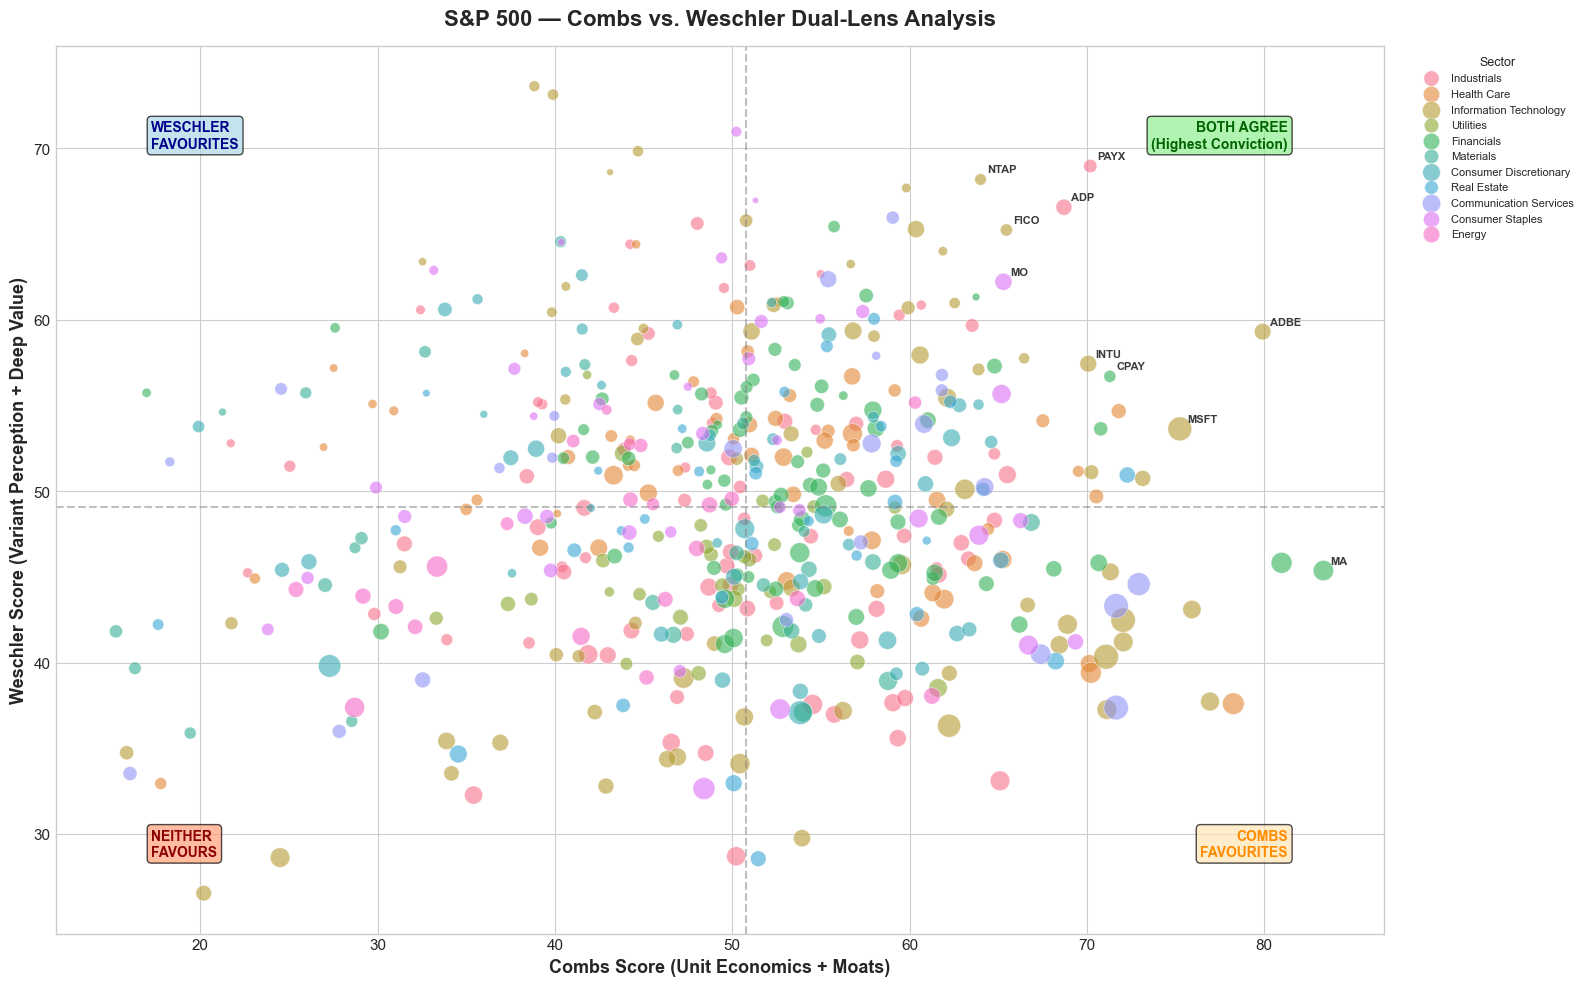

💾 Scatter plot saved to /Users/brendonmuur/Desktop/output/combs_vs_weschler_scatter.png


In [7]:
# ============================================================
# Cell 7 — Scatter Plot: Combs vs. Weschler
# ============================================================

fig, ax = plt.subplots(figsize=(16, 10))
sectors = df['sector'].dropna().unique()
sector_colours = dict(zip(sectors, sns.color_palette('husl', len(sectors))))
log_mcap = np.log10(df['market_cap'].clip(lower=1e8))
size_norm = ((log_mcap - log_mcap.min()) / (log_mcap.max() - log_mcap.min())) * 300 + 20

for sector in sectors:
    mask = df['sector'] == sector
    ax.scatter(df.loc[mask, 'combs_score'], df.loc[mask, 'weschler_score'],
              s=size_norm[mask], alpha=0.6, label=sector,
              color=sector_colours[sector], edgecolors='white', linewidth=0.5)

ax.axvline(df['combs_score'].median(), color='grey', linestyle='--', alpha=0.5)
ax.axhline(df['weschler_score'].median(), color='grey', linestyle='--', alpha=0.5)

pad = 2
ax.text(df['combs_score'].max()-pad, df['weschler_score'].max()-pad, 'BOTH AGREE\n(Highest Conviction)', ha='right', va='top', fontsize=10, fontweight='bold', color='darkgreen', bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))
ax.text(pad+df['combs_score'].min(), df['weschler_score'].max()-pad, 'WESCHLER\nFAVOURITES', ha='left', va='top', fontsize=10, fontweight='bold', color='darkblue', bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))
ax.text(df['combs_score'].max()-pad, pad+df['weschler_score'].min(), 'COMBS\nFAVOURITES', ha='right', va='bottom', fontsize=10, fontweight='bold', color='darkorange', bbox=dict(boxstyle='round,pad=0.3', facecolor='moccasin', alpha=0.7))
ax.text(pad+df['combs_score'].min(), pad+df['weschler_score'].min(), 'NEITHER\nFAVOURS', ha='left', va='bottom', fontsize=10, fontweight='bold', color='darkred', bbox=dict(boxstyle='round,pad=0.3', facecolor='lightsalmon', alpha=0.7))

for t, r in df.nlargest(10, 'combined_score').iterrows():
    ax.annotate(t, (r['combs_score'], r['weschler_score']), fontsize=8, fontweight='bold', alpha=0.9, xytext=(5,5), textcoords='offset points')

ax.set_xlabel('Combs Score (Unit Economics + Moats)', fontsize=13, fontweight='bold')
ax.set_ylabel('Weschler Score (Variant Perception + Deep Value)', fontsize=13, fontweight='bold')
ax.set_title('S&P 500 — Combs vs. Weschler Dual-Lens Analysis', fontsize=16, fontweight='bold', pad=15)
ax.legend(title='Sector', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title_fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'combs_vs_weschler_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Scatter plot saved to {OUTPUT_DIR}/combs_vs_weschler_scatter.png')

In [8]:
# ============================================================
# Cell 8 — Top 10 Lists
# ============================================================

def display_top_list(title, df_subset, score_col, sub_score_cols, n=10):
    top = df_subset.nlargest(n, score_col)
    print(f'\n{"="*80}')
    print(f'  {title}')
    print(f'{"="*80}')
    for rank, (ticker, row) in enumerate(top.iterrows(), 1):
        pe_str = f'PE: {row["trailing_pe"]:.1f}' if not pd.isna(row.get('trailing_pe')) else ''
        print(f'\n  #{rank} {ticker} — {row.get("company","")} ({row.get("sector","")})')
        print(f'      Score: {row[score_col]:.1f}/100  |  Mkt Cap: ${row["market_cap"]/1e9:.1f}B  {pe_str}')
        subs = ' | '.join([f'{c.split("_",1)[-1]}: {row[c]:.1f}' for c in sub_score_cols if c in row.index and not pd.isna(row[c])])
        print(f'      Sub-scores: {subs}')
        metrics = []
        if not pd.isna(row.get('roic')): metrics.append(f'ROIC: {row["roic"]*100:.1f}%')
        if not pd.isna(row.get('fcf_yield')): metrics.append(f'FCF Yield: {row["fcf_yield"]*100:.1f}%')
        if not pd.isna(row.get('operating_margin')): metrics.append(f'Op Margin: {row["operating_margin"]*100:.1f}%')
        if not pd.isna(row.get('drawdown_52w')): metrics.append(f'52w Draw: {row["drawdown_52w"]*100:.1f}%')
        if metrics: print(f'      Metrics: {" | ".join(metrics)}')

combs_sub = ['combs_unit_economics','combs_frictionless','combs_capital_allocation','combs_moat']
weschler_sub = ['weschler_variant','weschler_complexity','weschler_distressed','weschler_quality','weschler_compounding']

display_top_list('🎯 TOP 10 COMBS-STYLE PICKS', df, 'combs_score', combs_sub)
display_top_list('🔍 TOP 10 WESCHLER-STYLE PICKS', df, 'weschler_score', weschler_sub)
display_top_list('🏆 TOP 10 CONSENSUS PICKS (Both Lenses)', df, 'combined_score', combs_sub + weschler_sub)

# Undervalued flags
undervalued = df[((df['combs_score'] >= 75) | (df['weschler_score'] >= 75)) & (df['drawdown_52w'] <= -0.20)]
print(f'\n{"="*80}')
print(f'  ⚠️  UNDERVALUED FLAGS (Score >75 AND >20% below 52-week high)')
print(f'{"="*80}')
if len(undervalued) > 0:
    for t, r in undervalued.sort_values('combined_score', ascending=False).iterrows():
        print(f'  {t:6s} | {r.get("company",""):30s} | Combs: {r["combs_score"]:.0f} | Weschler: {r["weschler_score"]:.0f} | Draw: {r["drawdown_52w"]*100:.1f}%')
else:
    print('  No stocks currently meet both criteria.')


  🎯 TOP 10 COMBS-STYLE PICKS

  #1 MA — Mastercard Incorporated (Financials)
      Score: 83.3/100  |  Mkt Cap: $445.0B  PE: 30.2
      Sub-scores: unit_economics: 23.1 | frictionless: 21.0 | capital_allocation: 19.0 | moat: 20.2
      Metrics: ROIC: 97.2% | FCF Yield: 3.7% | Op Margin: 59.5% | 52w Draw: -15.9%

  #2 V — Visa Inc. (Financials)
      Score: 81.0/100  |  Mkt Cap: $586.8B  PE: 28.6
      Sub-scores: unit_economics: 24.2 | frictionless: 19.0 | capital_allocation: 18.1 | moat: 19.7
      Metrics: ROIC: 47.9% | FCF Yield: 3.7% | Op Margin: 66.4% | 52w Draw: -16.0%

  #3 ADBE — Adobe Inc. (Information Technology)
      Score: 79.9/100  |  Mkt Cap: $91.9B  PE: 13.1
      Sub-scores: unit_economics: 22.5 | frictionless: 15.6 | capital_allocation: 22.9 | moat: 18.9
      Metrics: ROIC: 55.4% | FCF Yield: 10.7% | Op Margin: 36.6% | 52w Draw: -45.7%

  #4 LLY — Eli Lilly and Company (Health Care)
      Score: 78.3/100  |  Mkt Cap: $840.8B  PE: 41.0
      Sub-scores: unit_economic

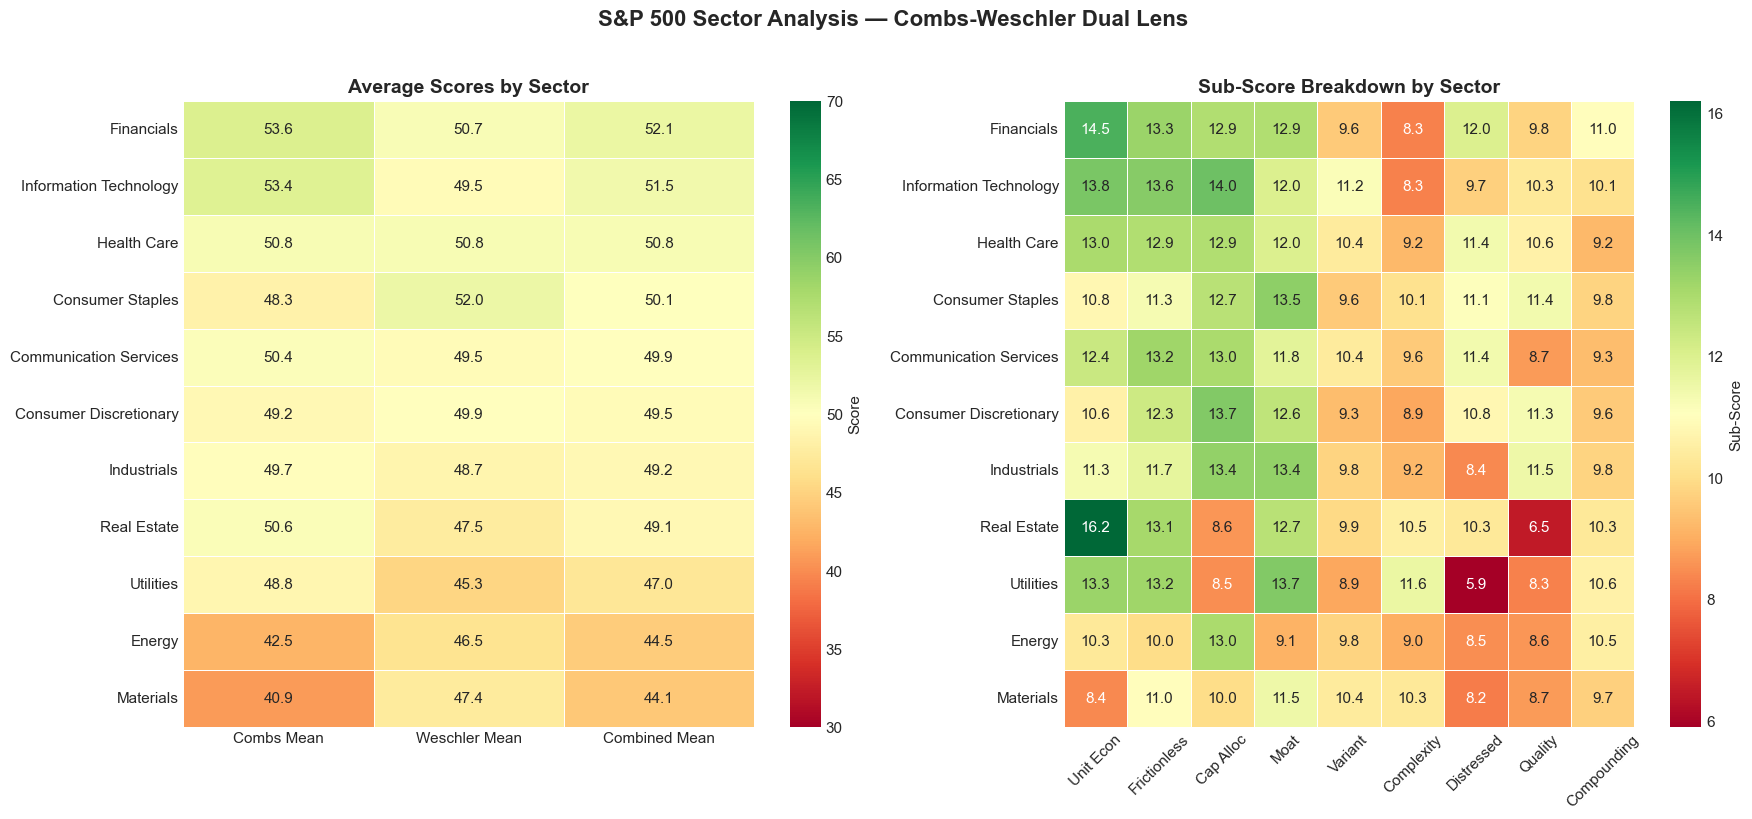


📊 Sector Summary:
                        Combs Mean  Combs Median  Count  Weschler Mean  Weschler Median  Combined Mean
sector                                                                                                
Financials                    53.6          53.3     76           50.7             50.4           52.1
Information Technology        53.4          53.9     73           49.5             50.1           51.5
Health Care                   50.8          51.8     58           50.8             51.7           50.8
Consumer Staples              48.3          48.9     36           52.0             49.6           50.1
Communication Services        50.4          57.3     23           49.5             51.7           49.9
Consumer Discretionary        49.2          51.3     48           49.9             51.6           49.5
Industrials                   49.7          49.8     79           48.7             47.9           49.2
Real Estate                   50.6          51.3     3

In [9]:
# ============================================================
# Cell 9 — Sector Heatmap
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sector_scores = df.groupby('sector').agg({'combs_score':['mean','median','count'],'weschler_score':['mean','median'],'combined_score':['mean']}).round(1)
sector_scores.columns = ['Combs Mean','Combs Median','Count','Weschler Mean','Weschler Median','Combined Mean']
sector_scores = sector_scores.sort_values('Combined Mean', ascending=False)

sns.heatmap(sector_scores[['Combs Mean','Weschler Mean','Combined Mean']], annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[0], linewidths=0.5, vmin=30, vmax=70, cbar_kws={'label': 'Score'})
axes[0].set_title('Average Scores by Sector', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

sub_scores = df.groupby('sector').agg({'combs_unit_economics':'mean','combs_frictionless':'mean','combs_capital_allocation':'mean','combs_moat':'mean','weschler_variant':'mean','weschler_complexity':'mean','weschler_distressed':'mean','weschler_quality':'mean','weschler_compounding':'mean'}).round(1)
sub_scores.columns = ['Unit Econ','Frictionless','Cap Alloc','Moat','Variant','Complexity','Distressed','Quality','Compounding']
sub_scores = sub_scores.loc[sector_scores.index]

sns.heatmap(sub_scores, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1], linewidths=0.5, cbar_kws={'label': 'Sub-Score'})
axes[1].set_title('Sub-Score Breakdown by Sector', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('S&P 500 Sector Analysis — Combs-Weschler Dual Lens', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sector_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Sector Summary:')
print(sector_scores.to_string())
print(f'\n💾 Heatmap saved to {OUTPUT_DIR}/sector_heatmap.png')

## Phase 5: Deep Dive Template


  DEEP DIVE: AAPL — Apple Inc.

📋 OVERVIEW
   Sector: Information Technology | Sub-Industry: Technology Hardware, Storage & Peripherals
   Market Cap: $3828.5B
   Business: Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories worldwide. The company offers iPhone, a line of smartphones; Mac, a line of personal ...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Combs Score:    72.0/100  🏆
   🟡 Weschler Score: 42.5/100  
   🟡 Combined Score: 57.3/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Unit Economics:     18.7/25
     ★ Gross Margin:    46.9%   (w

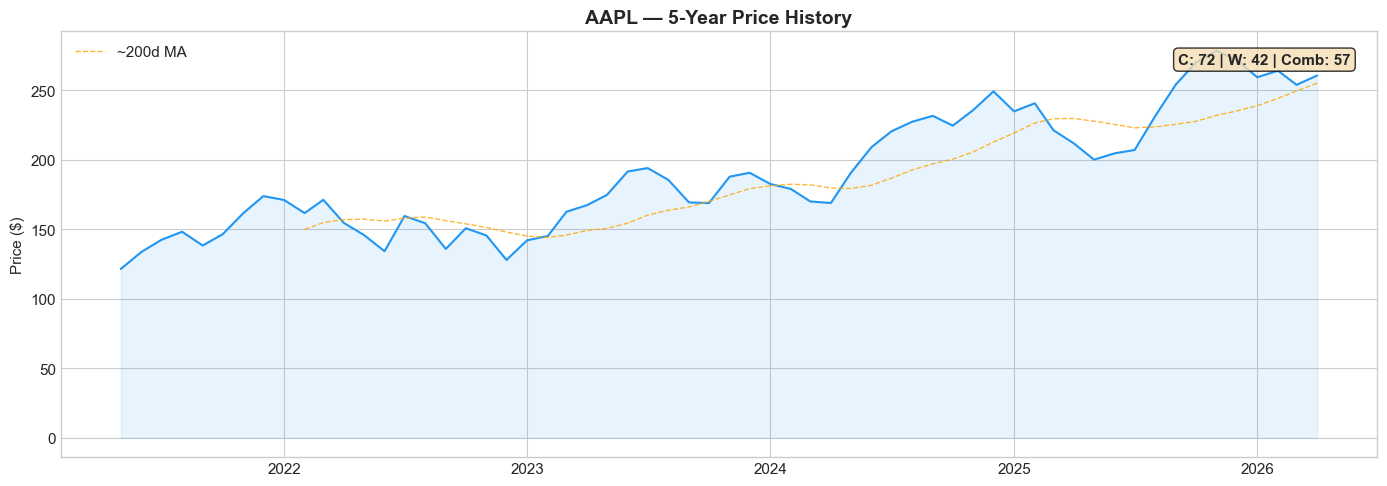

company                                                            Apple Inc.
sector                                                 Information Technology
market_cap                                                      3828515864576
description                 Apple Inc. designs, manufactures, and markets ...
trailing_pe                                                         33.013943
forward_pe                                                          27.928572
peg_ratio                                                                 NaN
price_to_book                                                        43.42781
price_to_sales                                                        8.78872
beta                                                                    1.109
dividend_yield                                                            0.4
short_percent                                                          0.0085
analyst_count                                                   

In [10]:
# ============================================================
# Cell 10 — Single Stock Deep Dive Function (Colour-Coded)
# ============================================================

def _signal(val, green, yellow_lo):
    """Return colour signal emoji based on thresholds."""
    if pd.isna(val): return '⚪'
    if val >= green: return '🟢'
    if val >= yellow_lo: return '🟡'
    return '🔴'

def _signal_total(val, green, yellow_lo):
    """Return colour signal for total scores."""
    if pd.isna(val): return '⚪'
    if val >= green: return '🟢'
    if val >= yellow_lo: return '🟡'
    return '🔴'

def _bold(text, is_bold=False):
    """Mark text as bold (★) for highest-weighted metrics."""
    return f'★ {text}' if is_bold else f'  {text}'

def _verdict(combs, weschler, combined, quality):
    """Generate overall verdict."""
    if combined >= 60 and quality >= 14:
        return '✅ HIGH CONVICTION — Quality business at attractive valuation'
    elif combined >= 55 or (combs >= 65 and quality >= 12):
        return '⚠️  RESEARCH FURTHER — Promising but needs deeper due diligence'
    elif combined >= 50 and quality >= 10:
        return '🟡 MONITOR — Decent on one lens, watch for catalyst'
    elif quality < 10 and weschler > combs:
        return '❌ VALUE TRAP RISK — Low quality + distressed price = caution'
    else:
        return '❌ NOT COMPELLING — Neither lens strongly favours this stock'

def deep_dive(ticker):
    """Comprehensive deep-dive with colour-coded scores and bold weighting."""
    if ticker not in df.index:
        print(f'❌ {ticker} not found in dataset')
        return
    row = df.loc[ticker]
    data = raw_data.get(ticker, {})
    hist = data.get('history')

    print(f'\n{"="*85}')
    print(f'  DEEP DIVE: {ticker} — {row.get("company", "")}')
    print(f'{"="*85}')

    # Overview
    print(f'\n📋 OVERVIEW')
    print(f'   Sector: {row.get("sector", "N/A")} | Sub-Industry: {row.get("GICS Sub-Industry", "N/A")}')
    if not pd.isna(row['market_cap']): print(f'   Market Cap: ${row["market_cap"]/1e9:.1f}B')
    desc = row.get('description', '')
    if isinstance(desc, str) and len(desc) > 10:
        print(f'   Business: {desc[:200]}...' if len(desc) > 200 else f'   Business: {desc}')

    # Total Scores with colour
    cs, ws, cb = row['combs_score'], row['weschler_score'], row['combined_score']
    print(f'\n{"─"*85}')
    print(f'  📊 OVERALL SCORES')
    print(f'{"─"*85}')
    print(f'   {_signal_total(cs, 65, 45)} Combs Score:    {cs:.1f}/100  {"🏆" if row.get("combs_style_flag") else ""}')
    print(f'   {_signal_total(ws, 60, 40)} Weschler Score: {ws:.1f}/100  {"🏆" if row.get("weschler_style_flag") else ""}')
    print(f'   {_signal_total(cb, 60, 50)} Combined Score: {cb:.1f}/100')

    # Combs Breakdown with signals + bold weights
    print(f'\n{"─"*85}')
    print(f'  🎯 COMBS BREAKDOWN — "Is this a great business?"')
    print(f'  (★ = highest-weighted metric in sub-score)')
    print(f'{"─"*85}')

    ue = row['combs_unit_economics']
    print(f'   {_signal(ue, 18, 12)} Unit Economics:     {ue:.1f}/25')
    gm = row.get('gross_margin'); om = row.get('operating_margin'); nm = row.get('net_margin'); ms = row.get('margin_stability')
    if not pd.isna(gm): print(f'     {_bold("Gross Margin:    " + f"{gm*100:.1f}%", True)}   (wt: 30%)')
    if not pd.isna(om): print(f'     {_bold("Op Margin:       " + f"{om*100:.1f}%", True)}   (wt: 30%)')
    if not pd.isna(nm): print(f'     {_bold("Net Margin:      " + f"{nm*100:.1f}%", False)}  (wt: 20%)')
    if not pd.isna(ms): print(f'     {_bold("Margin Stability: " + f"{ms:.4f}", False)} (wt: 20%, lower=better)')

    fo = row['combs_frictionless']
    print(f'\n   {_signal(fo, 18, 12)} Frictionless Ops:   {fo:.1f}/25')
    rc3 = row.get('revenue_cagr_3y'); ra = row.get('revenue_acceleration')
    if not pd.isna(rc3): print(f'     {_bold("Rev CAGR 3y:     " + f"{rc3*100:.1f}%", True)}   (wt: 40%)')
    if not pd.isna(ra): print(f'     {_bold("Rev Acceleration: " + f"{ra*100:.1f}%", False)} (wt: 30%)')
    print(f'       Sector Position                    (wt: 30%)')

    ca = row['combs_capital_allocation']
    print(f'\n   {_signal(ca, 18, 12)} Capital Allocation: {ca:.1f}/25')
    roic = row.get('roic'); roe = row.get('roe'); fy = row.get('fcf_yield'); rr = row.get('reinvestment_rate')
    if not pd.isna(roic): print(f'     {_bold("ROIC:            " + f"{roic*100:.1f}%", True)}   (wt: 35%)')
    if not pd.isna(roe): print(f'     {_bold("ROE:             " + f"{roe*100:.1f}%", False)}  (wt: 25%)')
    if not pd.isna(fy): print(f'     {_bold("FCF Yield:       " + f"{fy*100:.1f}%", False)}  (wt: 25%)')
    if not pd.isna(rr): print(f'     {_bold("Reinvest Rate:   " + f"{rr*100:.1f}%", False)} (wt: 15%)')

    mo = row['combs_moat']
    print(f'\n   {_signal(mo, 18, 12)} Moat Strength:      {mo:.1f}/25')
    mt = row.get('margin_trend')
    if not pd.isna(ms): print(f'     {_bold("Margin Stability: " + f"{ms:.4f}", True)}  (wt: 35%, lower=better)')
    if not pd.isna(mt): print(f'     {_bold("Margin Trend:    " + f"{mt*100:.1f}%", False)}  (wt: 30%)')
    print(f'     {_bold("Competitive Pos  vs sector peers", True)} (wt: 35%)')

    # Weschler Breakdown with signals + bold weights
    print(f'\n{"─"*85}')
    print(f'  🔍 WESCHLER BREAKDOWN — "Is this mispriced?"')
    print(f'  (★ = highest-weighted metric in sub-score)')
    print(f'{"─"*85}')

    wv = row['weschler_variant']
    print(f'   {_signal(wv, 14, 8)} Variant Perception:  {wv:.1f}/20')
    pg = row.get('pe_gap'); pe = row.get('trailing_pe'); peg = row.get('peg_ratio')
    if not pd.isna(pg): print(f'     {_bold("PE Gap (fwd/trail): " + f"{pg*100:.1f}%", True)}  (wt: 35%)')
    if not pd.isna(pe): print(f'     {_bold("PE vs Sector", True)}                     (wt: 35%)')
    if not pd.isna(peg): print(f'     {_bold("PEG Ratio:       " + f"{peg:.2f}", False)}   (wt: 30%)')
    else: print(f'       PEG Ratio:       N/A              (wt: 30%)')

    wc = row['weschler_complexity']
    print(f'\n   {_signal(wc, 14, 8)} Complexity Discount: {wc:.1f}/20')
    ac = row.get('analyst_count'); si = row.get('short_percent'); az = row.get('altman_z')
    if not pd.isna(ac): print(f'     {_bold("Analyst Coverage: " + f"{ac:.0f}", True)}    (wt: 30%, lower=better)')
    if not pd.isna(si): print(f'     {_bold("Short Interest:  " + f"{si*100:.2f}%", False)} (wt: 25%)')
    if not pd.isna(az): print(f'     {_bold("Altman Z-Score:  " + f"{az:.2f}" + (" ⚠️ grey zone" if 1.0 <= az <= 3.0 else ""), False)} (wt: 20%)')
    print(f'       P/B vs Sector                      (wt: 25%)')

    wd = row['weschler_distressed']
    print(f'\n   {_signal(wd, 14, 8)} Distressed Value:    {wd:.1f}/20')
    dd = row.get('drawdown_52w'); pma = row.get('price_vs_200ma'); pb = row.get('price_to_book')
    if not pd.isna(dd): print(f'     {_bold("52w Drawdown:    " + f"{dd*100:.1f}%", True)}   (wt: 30%)')
    if not pd.isna(pma): print(f'     {_bold("vs 200d MA:      " + f"{pma*100:.1f}%", False)}  (wt: 25%)')
    if not pd.isna(fy): print(f'     {_bold("FCF Yield:       " + f"{fy*100:.1f}%", False)}  (wt: 25%)')
    if not pd.isna(pb): print(f'     {_bold("Price/Book:      " + f"{pb:.2f}", False)}   (wt: 20%, lower=better)')

    wq = row['weschler_quality']
    print(f'\n   {_signal(wq, 14, 8)} Business Quality:    {wq:.1f}/20  {"← KEY: is the business good underneath?" if wq >= 14 else "← ⚠️ quality concern" if wq < 10 else ""}')
    ec = row.get('earnings_consistency'); rs = row.get('revenue_stability'); ic = row.get('interest_coverage')
    if not pd.isna(roic): print(f'     {_bold("ROIC:            " + f"{roic*100:.1f}%", True)}   (wt: 30%)')
    if not pd.isna(ec): print(f'     {_bold("Earn Consistency: " + f"{ec:.2f}", False)}  (wt: 25%, 1.0=perfect)')
    if not pd.isna(rs): print(f'     {_bold("Rev Stability:   " + f"{rs:.2f}", False)}  (wt: 25%, 1.0=perfect)')
    if not pd.isna(ic): print(f'     {_bold("Interest Cover:  " + f"{ic:.1f}x", False)}  (wt: 20%)')

    wl = row['weschler_compounding']
    print(f'\n   {_signal(wl, 14, 8)} LT Compounding:      {wl:.1f}/20')
    ec5 = row.get('earnings_cagr_5y'); rc5 = row.get('revenue_cagr_5y'); dy = row.get('dividend_yield'); bvg = row.get('book_value_growth')
    if not pd.isna(ec5): print(f'     {_bold("Earn CAGR 5y:    " + f"{ec5*100:.1f}%", True)}   (wt: 30%)')
    if not pd.isna(rc5): print(f'     {_bold("Rev CAGR 5y:     " + f"{rc5*100:.1f}%", True)}   (wt: 30%)')
    if not pd.isna(bvg): print(f'     {_bold("Book Val Growth: " + f"{bvg*100:.1f}%", False)} (wt: 25%)')
    if not pd.isna(dy): print(f'     {_bold("Dividend Yield:  " + f"{dy*100:.2f}%", False)} (wt: 15%)')

    # Sector ranking
    sector = row.get('sector')
    if sector and not pd.isna(sector):
        peers = df[df['sector'] == sector]
        cr = (peers['combs_score'] >= row['combs_score']).sum()
        wr = (peers['weschler_score'] >= row['weschler_score']).sum()
        print(f'\n{"─"*85}')
        print(f'  📊 SECTOR RANK ({sector}, {len(peers)} peers)')
        print(f'     Combs:   #{cr}/{len(peers)}')
        print(f'     Weschler: #{wr}/{len(peers)}')

    # Bull / Bear
    all_subs = {'Unit Econ': row['combs_unit_economics']/25, 'Frictionless': row['combs_frictionless']/25,
                'Cap Alloc': row['combs_capital_allocation']/25, 'Moat': row['combs_moat']/25,
                'Variant': row['weschler_variant']/20, 'Complexity': row['weschler_complexity']/20,
                'Distressed': row['weschler_distressed']/20, 'Quality': row['weschler_quality']/20,
                'Compounding': row['weschler_compounding']/20}
    strengths = sorted(all_subs.items(), key=lambda x: x[1], reverse=True)[:3]
    weaknesses = sorted(all_subs.items(), key=lambda x: x[1])[:3]
    print(f'\n{"─"*85}')
    print(f'  🐂 TOP STRENGTHS:  {" | ".join([f"{n}: {s*100:.0f}%" for n,s in strengths])}')
    print(f'  🐻 KEY WEAKNESSES: {" | ".join([f"{n}: {s*100:.0f}%" for n,s in weaknesses])}')

    # VERDICT
    v = _verdict(cs, ws, cb, wq)
    print(f'\n{"═"*85}')
    print(f'  VERDICT: {v}')
    print(f'{"═"*85}')

    # Price chart
    if hist is not None and not hist.empty and len(hist) > 3:
        fig, ax1 = plt.subplots(figsize=(14, 5))
        prices = hist['Close'].dropna()
        ax1.plot(prices.index, prices.values, color='#2196F3', linewidth=1.5)
        ax1.fill_between(prices.index, prices.values, alpha=0.1, color='#2196F3')
        if len(prices) > 10:
            ma = prices.rolling(10).mean()
            ax1.plot(ma.index, ma.values, color='orange', linewidth=1, linestyle='--', alpha=0.8, label='~200d MA')
        ax1.set_title(f'{ticker} — 5-Year Price History', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Price ($)')
        # Colour the score box based on verdict
        box_color = 'lightgreen' if cb >= 60 else 'wheat' if cb >= 50 else 'lightsalmon'
        ax1.text(0.98, 0.95, f'C: {cs:.0f} | W: {ws:.0f} | Comb: {cb:.0f}',
                transform=ax1.transAxes, ha='right', va='top', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.8))
        ax1.legend(loc='upper left')
        plt.tight_layout()
        plt.show()

    return row

deep_dive('AAPL')

📗 TOP 5 COMBS-STYLE PICKS


  DEEP DIVE: MA — Mastercard Incorporated

📋 OVERVIEW
   Sector: Financials | Sub-Industry: Transaction & Payment Processing Services
   Market Cap: $445.0B
   Business: Mastercard Incorporated, a technology company, provides transaction processing and other payment-related products and services in the United States and internationally. The company offers products and...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Combs Score:    83.3/100  🏆
   🟡 Weschler Score: 45.4/100  
   🟢 Combined Score: 64.4/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Unit Economics:     23.1/25
     ★ Gro

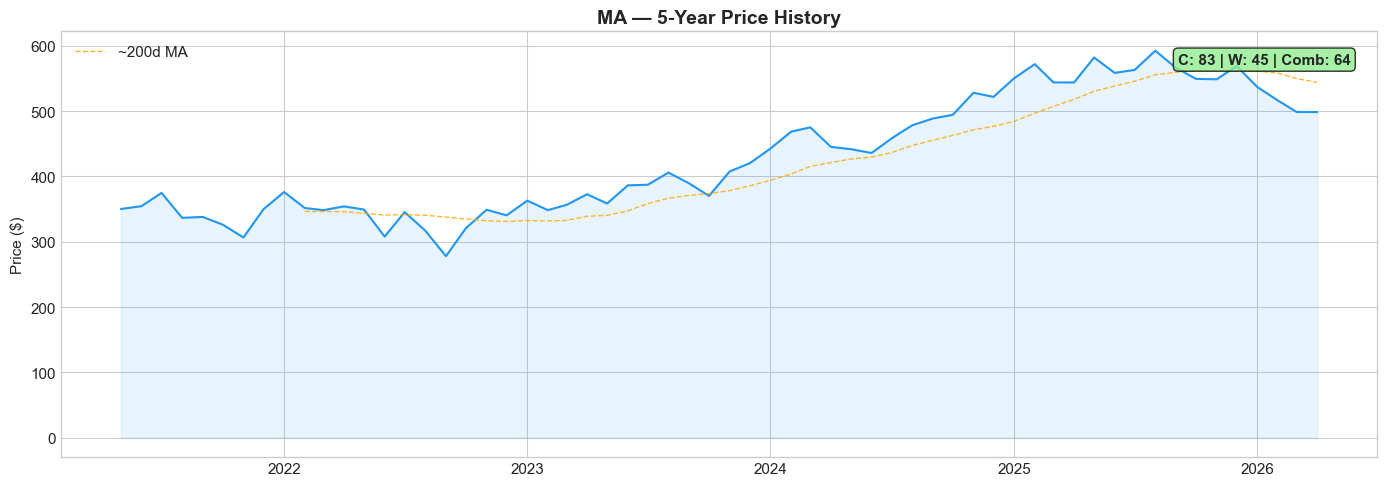


  DEEP DIVE: V — Visa Inc.

📋 OVERVIEW
   Sector: Financials | Sub-Industry: Transaction & Payment Processing Services
   Market Cap: $586.8B
   Business: Visa Inc. operates as a payment technology company in the United States and internationally. The company operates VisaNet, a transaction processing network that enables authorization, clearing, and se...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Combs Score:    81.0/100  🏆
   🟡 Weschler Score: 45.8/100  
   🟢 Combined Score: 63.4/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Unit Economics:     24.2/25
     ★ Gross Margin:    80.4%   (wt: 30%)
     ★ Op 

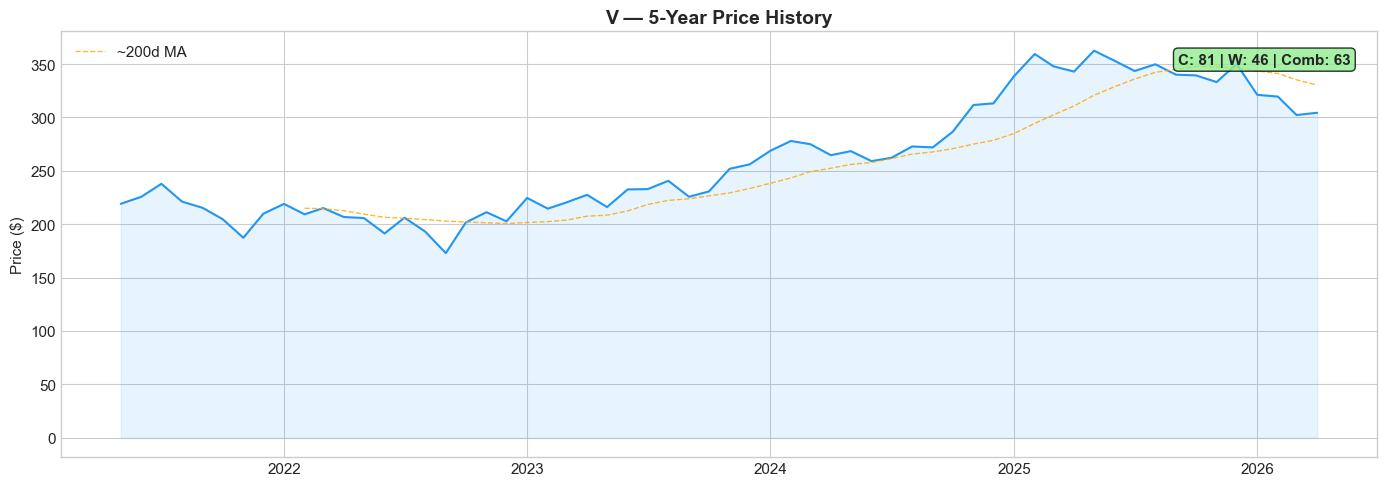


  DEEP DIVE: ADBE — Adobe Inc.

📋 OVERVIEW
   Sector: Information Technology | Sub-Industry: Application Software
   Market Cap: $91.9B
   Business: Adobe Inc. operates as a technology company worldwide. The Digital Media segment offers products and services that enable individuals, teams, and enterprises to create, publish, and promote content. T...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Combs Score:    79.9/100  🏆
   🟡 Weschler Score: 59.3/100  
   🟢 Combined Score: 69.6/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Unit Economics:     22.5/25
     ★ Gross Margin:    89.3%   (wt: 30%)
     ★ Op Margin

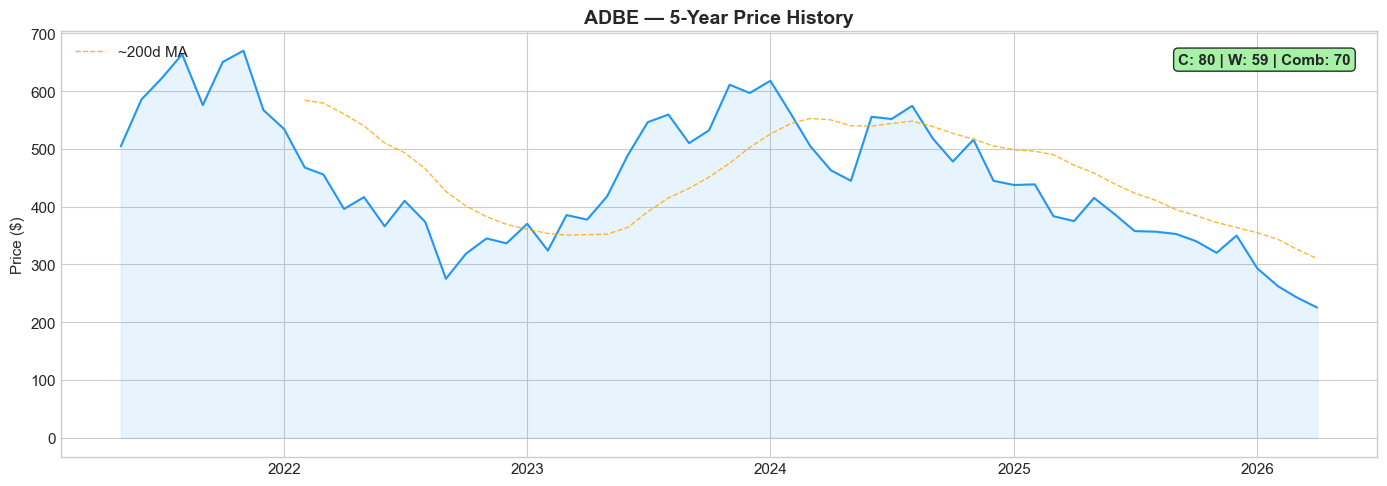


  DEEP DIVE: LLY — Eli Lilly and Company

📋 OVERVIEW
   Sector: Health Care | Sub-Industry: Pharmaceuticals
   Market Cap: $840.8B
   Business: Eli Lilly and Company discovers, develops, manufactures, and markets human pharmaceutical products in the United States, Europe, China, Japan, and internationally. The company offers cardiometabolic h...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Combs Score:    78.3/100  🏆
   🔴 Weschler Score: 37.6/100  
   🟡 Combined Score: 57.9/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Unit Economics:     19.6/25
     ★ Gross Margin:    83.0%   (wt: 30%)
     ★ Op Margin:    

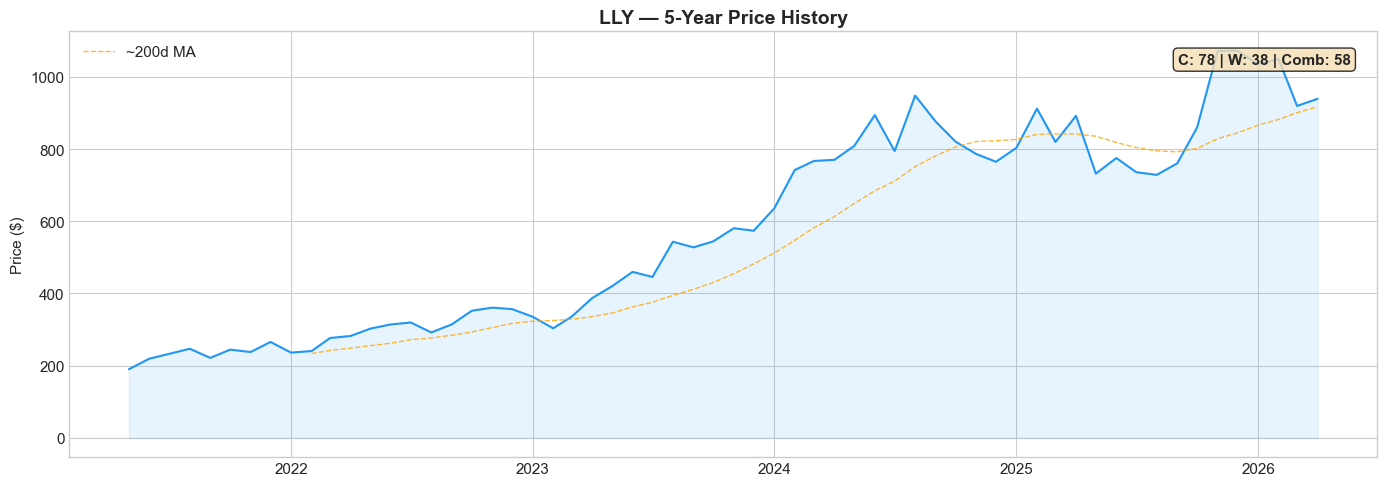


  DEEP DIVE: KLAC — KLA Corporation

📋 OVERVIEW
   Sector: Information Technology | Sub-Industry: Semiconductor Materials & Equipment
   Market Cap: $228.3B
   Business: KLA Corporation, together with its subsidiaries, designs, manufactures, and markets process control, process-enabling, and yield management solutions for the semiconductor and related electronics indu...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Combs Score:    76.9/100  🏆
   🔴 Weschler Score: 37.7/100  
   🟡 Combined Score: 57.3/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Unit Economics:     20.2/25
     ★ Gross Margin:    60.9%   (wt: 

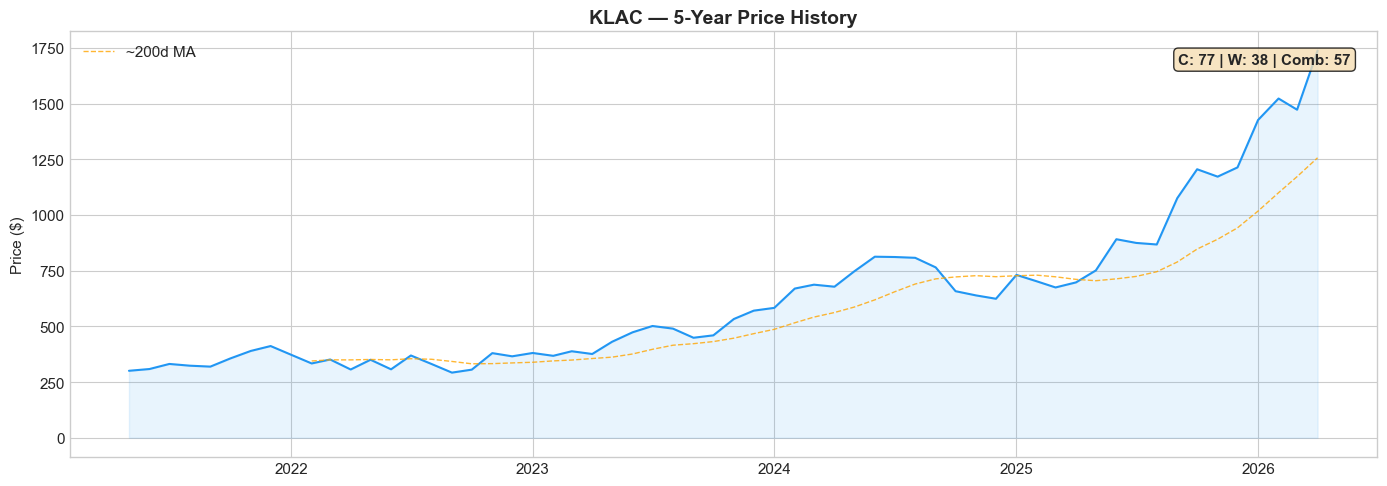



📘 TOP 5 WESCHLER-STYLE PICKS


  DEEP DIVE: SMCI — Super Micro Computer, Inc.

📋 OVERVIEW
   Sector: Information Technology | Sub-Industry: Technology Hardware, Storage & Peripherals
   Market Cap: $15.2B
   Business: Super Micro Computer, Inc., together with its subsidiaries, develops and sells server and storage solutions based on modular and open-standard architecture in the United States, Asia, Europe, and inte...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🔴 Combs Score:    38.8/100  
   🟢 Weschler Score: 73.6/100  
   🟡 Combined Score: 56.2/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🔴 Unit Economics:  

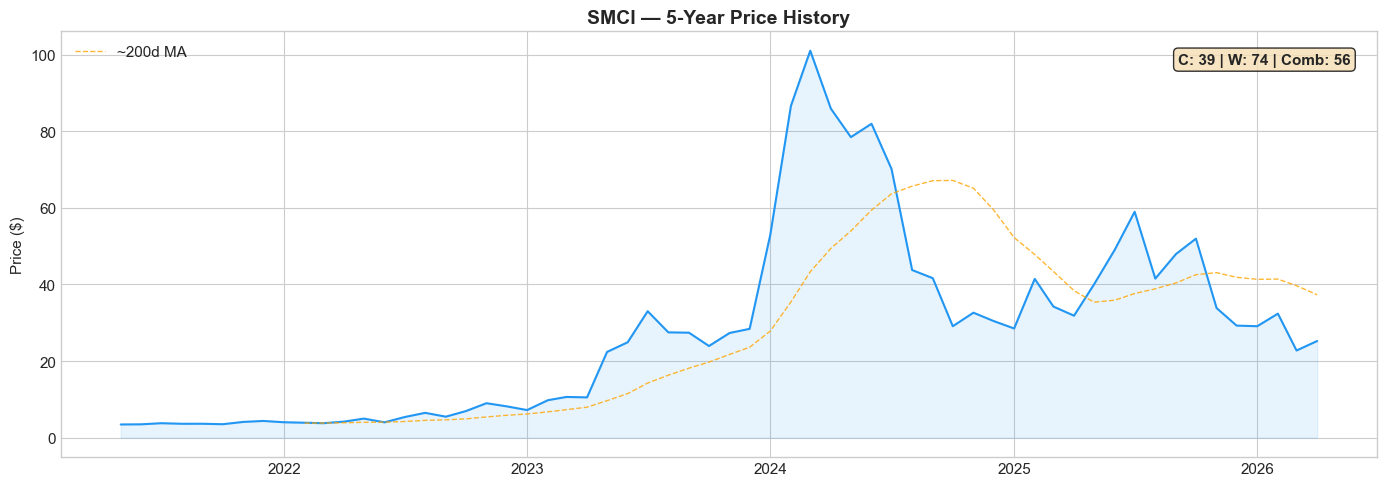


  DEEP DIVE: HPQ — HP Inc.

📋 OVERVIEW
   Sector: Information Technology | Sub-Industry: Technology Hardware, Storage & Peripherals
   Market Cap: $16.8B
   Business: HP Inc. provides personal computing, printing, 3D printing, hybrid work, gaming, and other related technologies in the United States and internationally. The company operates through three segments: P...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🔴 Combs Score:    39.9/100  
   🟢 Weschler Score: 73.1/100  
   🟡 Combined Score: 56.5/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🔴 Unit Economics:     7.3/25
     ★ Gross Margin:    20.6%   (wt: 30%)


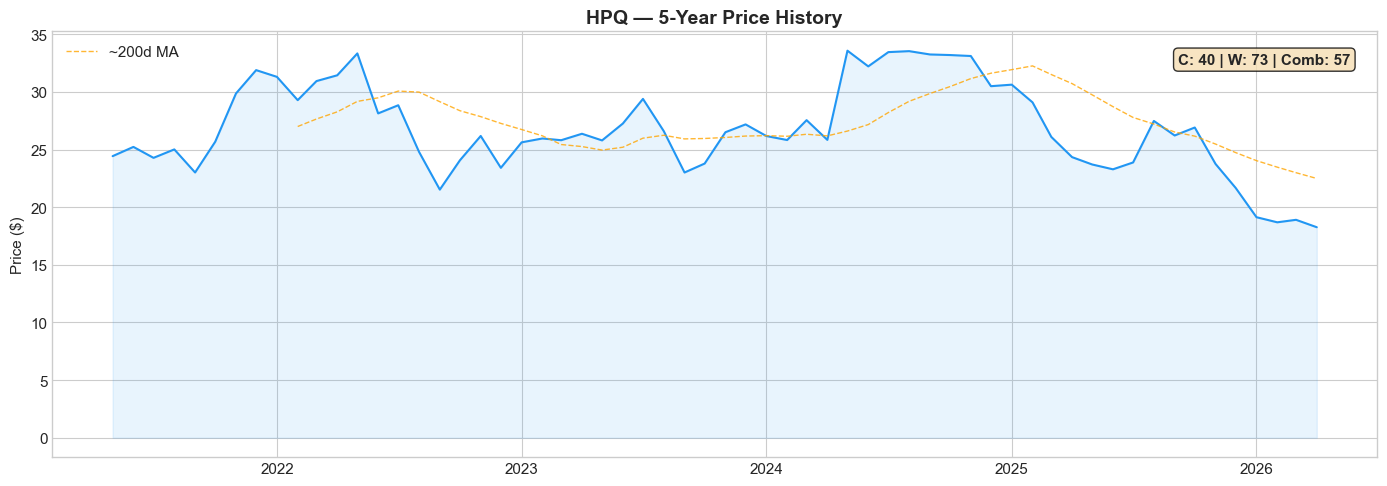


  DEEP DIVE: MKC — McCormick & Company, Incorporated

📋 OVERVIEW
   Sector: Consumer Staples | Sub-Industry: Packaged Foods & Meats
   Market Cap: $14.4B
   Business: McCormick & Company, Incorporated manufactures, markets, and distributes herbs, spices, seasoning mixes, condiments, and other flavorful products to the food industry. It operates in two segments, Con...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🟡 Combs Score:    50.2/100  
   🟢 Weschler Score: 71.0/100  
   🟢 Combined Score: 60.6/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🟡 Unit Economics:     12.4/25
     ★ Gross Margin:    37.9%   (wt: 30%)

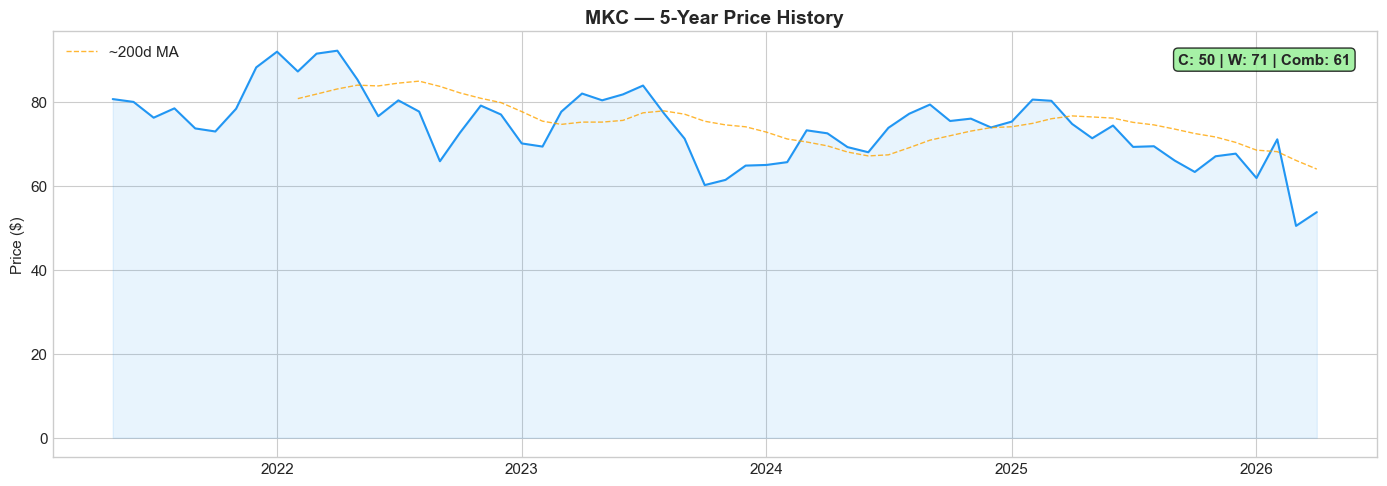


  DEEP DIVE: CDW — CDW Corporation

📋 OVERVIEW
   Sector: Information Technology | Sub-Industry: Technology Distributors
   Market Cap: $16.3B
   Business: CDW Corporation provides information technology (IT) solutions in the United States, the United Kingdom, and Canada. It operates through three segments: Commercial, Government, and Education. The comp...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🔴 Combs Score:    44.7/100  
   🟢 Weschler Score: 69.8/100  
   🟡 Combined Score: 57.3/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🔴 Unit Economics:     8.1/25
     ★ Gross Margin:    21.7%   (wt: 30%)
     ★ Op M

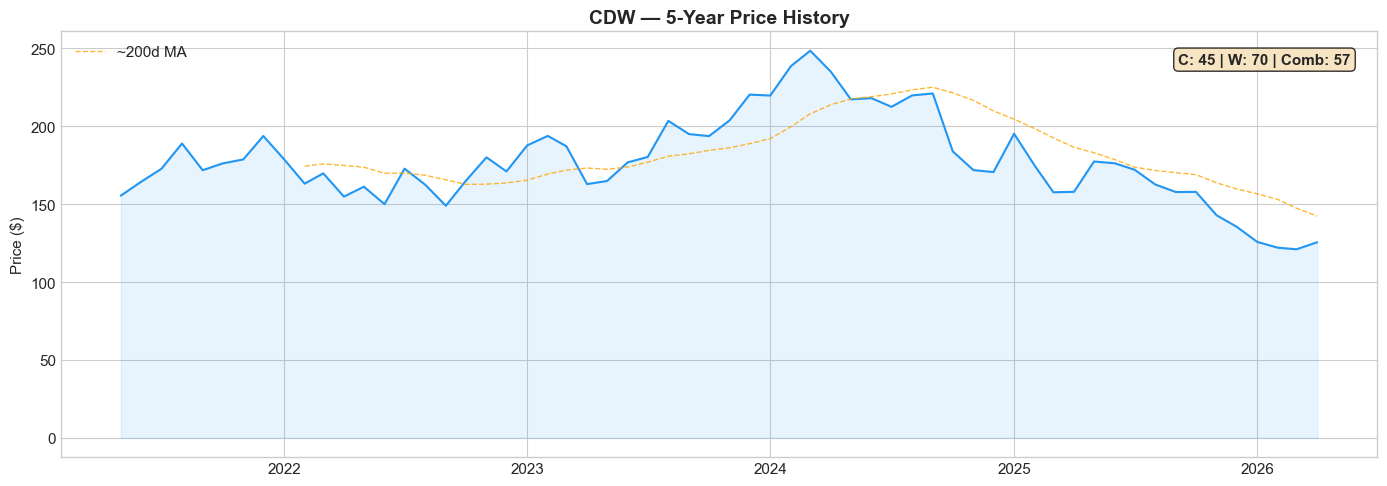


  DEEP DIVE: PAYX — Paychex, Inc.

📋 OVERVIEW
   Sector: Industrials | Sub-Industry: Human Resource & Employment Services
   Market Cap: $30.7B
   Business: Paychex, Inc., together with its subsidiaries, provides human capital management solutions (HCM) for payroll, employee benefits, human resources (HR), and insurance services for small to medium-sized ...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Combs Score:    70.2/100  🏆
   🟢 Weschler Score: 69.0/100  
   🟢 Combined Score: 69.6/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Unit Economics:     22.4/25
     ★ Gross Margin:    72.4%   (wt: 30%)
     ★ O

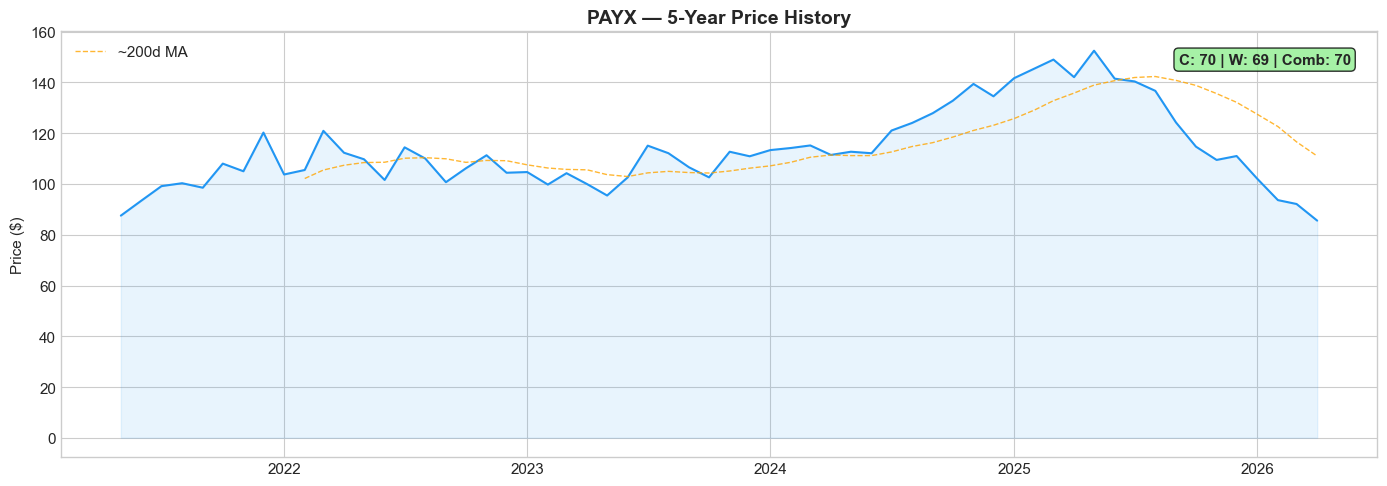

In [11]:
# ============================================================
# Cell 11 — Batch Deep Dive (Top 5 from each lens)
# ============================================================

print('📗 TOP 5 COMBS-STYLE PICKS\n')
for ticker in df.nlargest(5, 'combs_score').index:
    deep_dive(ticker)

print('\n\n📘 TOP 5 WESCHLER-STYLE PICKS\n')
for ticker in df.nlargest(5, 'weschler_score').index:
    deep_dive(ticker)

## Phase 6: Alerting & Monitoring

In [12]:
# ============================================================
# Cell 12 — Watchlist, History Tracking, Change Detection & Email Alerts
# ============================================================

import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

EMAIL_CONFIG = {
    'enabled': True,
    'to': 'brendon.muur@gmail.com',
    'from': 'brendon.muur@gmail.com',
    'subject_prefix': '[CW Screener]',
    'smtp_host': 'smtp.gmail.com',
    'smtp_port': 587,
    'smtp_user': os.environ.get('CW_SMTP_USER', ''),  # Set env var CW_SMTP_USER
    'smtp_pass': os.environ.get('CW_SMTP_PASS', ''),  # Set env var CW_SMTP_PASS
}

HISTORY_DIR = os.path.join(OUTPUT_DIR, 'history')
HISTORY_FILE = os.path.join(HISTORY_DIR, 'score_history.csv')
os.makedirs(HISTORY_DIR, exist_ok=True)

def send_alert_email(subject, body_text):
    """Send email alert."""
    cfg = EMAIL_CONFIG
    if not cfg['enabled'] or not cfg['smtp_user'] or not cfg['smtp_pass']:
        return False
    try:
        msg = MIMEMultipart('alternative')
        msg['Subject'] = f'{cfg["subject_prefix"]} {subject}'
        msg['From'] = cfg['from']
        msg['To'] = cfg['to']
        msg.attach(MIMEText(body_text, 'plain'))
        html_body = f'<html><body><pre style="font-family: Menlo, Monaco, monospace; font-size: 13px;">{body_text}</pre></body></html>'
        msg.attach(MIMEText(html_body, 'html'))
        with smtplib.SMTP(cfg['smtp_host'], cfg['smtp_port']) as server:
            server.starttls()
            server.login(cfg['smtp_user'], cfg['smtp_pass'])
            server.sendmail(cfg['from'], cfg['to'], msg.as_string())
        return True
    except Exception as e:
        print(f'  ⚠️  Email send failed: {e}')
        return False

def save_snapshot(df):
    """Save current scores as a timestamped snapshot."""
    run_date = datetime.now().strftime('%Y-%m-%d')
    run_ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    score_cols = ['company','sector','market_cap','combs_score','weschler_score','combined_score',
                  'combs_unit_economics','combs_frictionless','combs_capital_allocation','combs_moat',
                  'weschler_variant','weschler_complexity','weschler_distressed','weschler_quality','weschler_compounding',
                  'trailing_pe','forward_pe','roic','fcf_yield','gross_margin','operating_margin',
                  'revenue_cagr_3y','drawdown_52w','combs_style_flag','weschler_style_flag']
    avail = [c for c in score_cols if c in df.columns]
    snapshot = df[avail].copy()
    snapshot['run_date'] = run_date
    snapshot['run_timestamp'] = run_ts
    snapshot['ticker'] = snapshot.index
    if os.path.exists(HISTORY_FILE):
        existing = pd.read_csv(HISTORY_FILE)
        existing = existing[existing['run_date'] != run_date]
        combined = pd.concat([existing, snapshot.reset_index(drop=True)], ignore_index=True)
    else:
        combined = snapshot.reset_index(drop=True)
    combined.to_csv(HISTORY_FILE, index=False)
    snapshot_file = os.path.join(HISTORY_DIR, f'snapshot_{run_date}.csv')
    snapshot.to_csv(snapshot_file)
    return run_date

def load_history():
    if not os.path.exists(HISTORY_FILE):
        return None
    return pd.read_csv(HISTORY_FILE)

def get_previous_snapshot(days_back=7):
    history = load_history()
    if history is None or history.empty:
        return None, None
    dates = sorted(history['run_date'].unique())
    if len(dates) < 2:
        return None, None
    target = (datetime.now() - timedelta(days=days_back)).strftime('%Y-%m-%d')
    closest = min(dates[:-1], key=lambda d: abs((datetime.strptime(d, '%Y-%m-%d') - datetime.strptime(target, '%Y-%m-%d')).days))
    return history[history['run_date'] == closest].set_index('ticker'), closest

def build_weekly_report(current_df):
    """Build the full weekly email report."""
    run_date = datetime.now().strftime('%Y-%m-%d')
    lines = []
    lines.append(f'COMBS-WESCHLER SCREENER — WEEKLY REPORT')
    lines.append(f'Date: {run_date}')
    lines.append(f'Stocks analysed: {len(current_df)}')
    
    history = load_history()
    dates = sorted(history['run_date'].unique()) if history is not None else []
    lines.append(f'History: {len(dates)} snapshots')
    
    prev_week, prev_week_date = get_previous_snapshot(days_back=7)
    prev_month, prev_month_date = get_previous_snapshot(days_back=30)
    
    has_changes = False
    
    # ═══════════════════════════════════════════════════════
    # SECTION 1: TOP 20 ROSTER CHANGES (Combs + Weschler)
    # ═══════════════════════════════════════════════════════
    lines.append(f'\n{"═"*70}')
    lines.append(f'  CHANGES — TOP 20 ROSTER')
    lines.append(f'{"═"*70}')
    
    if prev_week is not None:
        lines.append(f'\n  Comparing to: {prev_week_date}')
        
        # Combs Top 20 changes
        curr_combs_20 = set(current_df.nlargest(20, 'combs_score').index)
        prev_combs_20 = set(prev_week.nlargest(20, 'combs_score').index) if 'combs_score' in prev_week.columns else set()
        
        combs_entered = curr_combs_20 - prev_combs_20
        combs_exited = prev_combs_20 - curr_combs_20
        
        lines.append(f'\n  🎯 COMBS TOP 20 (Best Businesses):')
        if combs_entered:
            has_changes = True
            for t in sorted(combs_entered):
                if t in current_df.index:
                    r = current_df.loc[t]
                    lines.append(f'    🆕 IN:  {t:<7} {str(r.get("company",""))[:28]:<29} Score: {r["combs_score"]:.1f}  ROIC: {r["roic"]*100:.0f}%' if not pd.isna(r.get('roic')) else f'    🆕 IN:  {t:<7} {str(r.get("company",""))[:28]:<29} Score: {r["combs_score"]:.1f}')
        if combs_exited:
            has_changes = True
            for t in sorted(combs_exited):
                prev_score = prev_week.loc[t, 'combs_score'] if t in prev_week.index else 0
                lines.append(f'    🚪 OUT: {t:<7} (was Score: {prev_score:.1f})')
        if not combs_entered and not combs_exited:
            lines.append(f'    No changes this week.')
        
        # Weschler Top 20 changes
        curr_weschler_20 = set(current_df.nlargest(20, 'weschler_score').index)
        prev_weschler_20 = set(prev_week.nlargest(20, 'weschler_score').index) if 'weschler_score' in prev_week.columns else set()
        
        weschler_entered = curr_weschler_20 - prev_weschler_20
        weschler_exited = prev_weschler_20 - curr_weschler_20
        
        lines.append(f'\n  🔍 WESCHLER TOP 20 (Mispriced / Contrarian):')
        if weschler_entered:
            has_changes = True
            for t in sorted(weschler_entered):
                if t in current_df.index:
                    r = current_df.loc[t]
                    dd = f'Draw: {r["drawdown_52w"]*100:.0f}%' if not pd.isna(r.get('drawdown_52w')) else ''
                    lines.append(f'    🆕 IN:  {t:<7} {str(r.get("company",""))[:28]:<29} Score: {r["weschler_score"]:.1f}  {dd}')
        if weschler_exited:
            has_changes = True
            for t in sorted(weschler_exited):
                prev_score = prev_week.loc[t, 'weschler_score'] if t in prev_week.index else 0
                lines.append(f'    🚪 OUT: {t:<7} (was Score: {prev_score:.1f})')
        if not weschler_entered and not weschler_exited:
            lines.append(f'    No changes this week.')
    else:
        lines.append(f'\n  ℹ️  First run — no previous data to compare.')
    
    # ═══════════════════════════════════════════════════════
    # SECTION 2: HIGHEST CONVICTION (Combs 60+ AND Weschler 60+)
    # ═══════════════════════════════════════════════════════
    lines.append(f'\n{"═"*70}')
    lines.append(f'  HIGHEST CONVICTION — Combs ≥60 AND Weschler ≥60')
    lines.append(f'  (Both lenses agree: quality business + attractive price)')
    lines.append(f'{"═"*70}')
    
    conviction = current_df[(current_df['combs_score'] >= 60) & (current_df['weschler_score'] >= 60)].sort_values('combined_score', ascending=False)
    
    if len(conviction) > 0:
        lines.append(f'\n  {"#":>3}  {"Ticker":<7} {"Company":<30} {"Combs":>6} {"Wesch":>6} {"Comb":>6}  {"ROIC":>6} {"52wDr":>7} {"FCFYld":>7}')
        lines.append(f'  {"-"*85}')
        for i, (t, r) in enumerate(conviction.head(20).iterrows(), 1):
            roic = f'{r["roic"]*100:.0f}%' if not pd.isna(r.get('roic')) else '  —'
            dd = f'{r["drawdown_52w"]*100:.0f}%' if not pd.isna(r.get('drawdown_52w')) else '  —'
            fy = f'{r["fcf_yield"]*100:.1f}%' if not pd.isna(r.get('fcf_yield')) else '  —'
            lines.append(f'  {i:>3}. {t:<7} {str(r.get("company",""))[:29]:<30} {r["combs_score"]:>5.1f} {r["weschler_score"]:>5.1f} {r["combined_score"]:>5.1f}  {roic:>6} {dd:>7} {fy:>7}')
        
        # Flag new entries to conviction list vs last week
        if prev_week is not None and 'combs_score' in prev_week.columns and 'weschler_score' in prev_week.columns:
            prev_conviction = set(prev_week[(prev_week['combs_score'] >= 60) & (prev_week['weschler_score'] >= 60)].index)
            curr_conviction = set(conviction.index)
            new_conviction = curr_conviction - prev_conviction
            lost_conviction = prev_conviction - curr_conviction
            if new_conviction:
                lines.append(f'\n  🆕 New to Highest Conviction this week:')
                for t in sorted(new_conviction):
                    if t in current_df.index:
                        lines.append(f'     {t} ({current_df.loc[t, "combined_score"]:.1f})')
            if lost_conviction:
                lines.append(f'\n  🚪 Dropped from Highest Conviction:')
                for t in sorted(lost_conviction):
                    lines.append(f'     {t}')
    else:
        lines.append(f'\n  No stocks currently meet both thresholds (Combs ≥60 AND Weschler ≥60).')
    
    # ═══════════════════════════════════════════════════════
    # SECTION 3: WEEKLY SUMMARY
    # ═══════════════════════════════════════════════════════
    lines.append(f'\n{"═"*70}')
    lines.append(f'  WEEKLY SUMMARY')
    lines.append(f'{"═"*70}')
    
    best = current_df['combined_score'].idxmax()
    lines.append(f'\n  Top Combined:  {best} ({current_df.loc[best, "combined_score"]:.1f})')
    lines.append(f'  Top Combs:     {current_df["combs_score"].idxmax()} ({current_df["combs_score"].max():.1f})')
    lines.append(f'  Top Weschler:  {current_df["weschler_score"].idxmax()} ({current_df["weschler_score"].max():.1f})')
    lines.append(f'  Combs flags:   {current_df["combs_style_flag"].sum()}')
    lines.append(f'  Weschler flags: {current_df["weschler_style_flag"].sum()}')
    lines.append(f'  Conviction stocks (C≥60 & W≥60): {len(conviction)}')
    
    # Score range summary
    lines.append(f'\n  Score Ranges:')
    lines.append(f'    Combs:    {current_df["combs_score"].min():.1f} – {current_df["combs_score"].max():.1f} (mean {current_df["combs_score"].mean():.1f})')
    lines.append(f'    Weschler: {current_df["weschler_score"].min():.1f} – {current_df["weschler_score"].max():.1f} (mean {current_df["weschler_score"].mean():.1f})')
    lines.append(f'    Combined: {current_df["combined_score"].min():.1f} – {current_df["combined_score"].max():.1f} (mean {current_df["combined_score"].mean():.1f})')
    
    # Top 10 by each lens
    lines.append(f'\n  Top 10 Combs (Best Businesses):')
    for i, (t, r) in enumerate(current_df.nlargest(10, 'combs_score').iterrows(), 1):
        lines.append(f'    {i:>2}. {t:<7} {r["combs_score"]:.1f}  {str(r.get("company",""))[:30]}')
    
    lines.append(f'\n  Top 10 Weschler (Mispriced/Contrarian):')
    for i, (t, r) in enumerate(current_df.nlargest(10, 'weschler_score').iterrows(), 1):
        lines.append(f'    {i:>2}. {t:<7} {r["weschler_score"]:.1f}  {str(r.get("company",""))[:30]}')
    
    # Month-over-month big movers (if available)
    if prev_month is not None and prev_month_date != prev_week_date:
        lines.append(f'\n  Monthly Big Movers (vs {prev_month_date}, >5pt combined):')
        common = set(current_df.index) & set(prev_month.index)
        movers = []
        for t in common:
            if 'combined_score' in prev_month.columns:
                delta = current_df.loc[t, 'combined_score'] - prev_month.loc[t, 'combined_score']
                if abs(delta) > 5:
                    movers.append((t, prev_month.loc[t, 'combined_score'], current_df.loc[t, 'combined_score'], delta))
        if movers:
            for t, prev, curr, delta in sorted(movers, key=lambda x: -abs(x[3]))[:10]:
                arrow = '📈' if delta > 0 else '📉'
                lines.append(f'    {arrow} {t:<7} {prev:.1f} → {curr:.1f} ({delta:+.1f})')
        else:
            lines.append(f'    No moves >5pt this month.')
    
    lines.append(f'\n{"═"*70}')
    lines.append(f'  Run: deep_dive("TICKER") in notebook for detailed analysis')
    lines.append(f'  📱 Dashboard: https://combs-weschler-screener-mhmd9c2vs8k9mfzngbqrqp.streamlit.app/')
    lines.append(f'  Next auto-run: Saturday 8:00 AM')
    lines.append(f'{"═"*70}')
    
    return '\n'.join(lines), has_changes

def save_watchlist(df, filepath=WATCHLIST_FILE):
    watchlist_cols = ['company','sector','market_cap','combs_score','weschler_score','combined_score',
                      'trailing_pe','forward_pe','roic','fcf_yield','gross_margin','operating_margin',
                      'revenue_cagr_3y','drawdown_52w','combs_style_flag','weschler_style_flag']
    avail = [c for c in watchlist_cols if c in df.columns]
    top_picks = df.nlargest(50, 'combined_score')[avail].copy()
    top_picks['timestamp'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    top_picks['run_date'] = datetime.now().strftime('%Y-%m-%d')
    top_picks.to_csv(filepath)
    return top_picks

# --- Execute ---
run_date = save_snapshot(df)
print(f'💾 Snapshot saved for {run_date}')

# Build report
report_text, has_roster_changes = build_weekly_report(df)

# Print to notebook
print(report_text)

# Send email (always, even if no changes)
subject = 'Weekly Report'
if has_roster_changes:
    subject = '⚠️ Top 20 Roster Changes + Weekly Report'
sent = send_alert_email(subject, report_text)
if sent:
    print(f'\n📧 Email sent to {EMAIL_CONFIG["to"]}')
else:
    print(f'\n⚠️  Email not sent (check EMAIL_CONFIG)')

# Save report to file
report_file = os.path.join(HISTORY_DIR, f'report_{run_date}.txt')
with open(report_file, 'w') as f:
    f.write(report_text)

# Save watchlist
watchlist = save_watchlist(df)

# Final summary
history = load_history()
n_snapshots = len(history['run_date'].unique()) if history is not None else 1
best = df['combined_score'].idxmax()
conviction_count = len(df[(df['combs_score'] >= 60) & (df['weschler_score'] >= 60)])

print(f'\n  📁 Files saved:')
print(f'  • {WATCHLIST_FILE}')
print(f'  • {HISTORY_FILE} ({n_snapshots} snapshots)')
print(f'  • {report_file}')
print(f'\n  🔄 Auto-runs: Saturday 8:00 AM')
print(f'  📊 deep_dive("TICKER") for any stock')


  DEEP DIVE: PAYX — Paychex, Inc.

📋 OVERVIEW
   Sector: Industrials | Sub-Industry: Human Resource & Employment Services
   Market Cap: $30.7B
   Business: Paychex, Inc., together with its subsidiaries, provides human capital management solutions (HCM) for payroll, employee benefits, human resources (HR), and insurance services for small to medium-sized ...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Combs Score:    70.2/100  🏆
   🟢 Weschler Score: 69.0/100  
   🟢 Combined Score: 69.6/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Unit Economics:     22.4/25
     ★ Gross Margin:    72.4%   (wt: 30%)
     ★ O

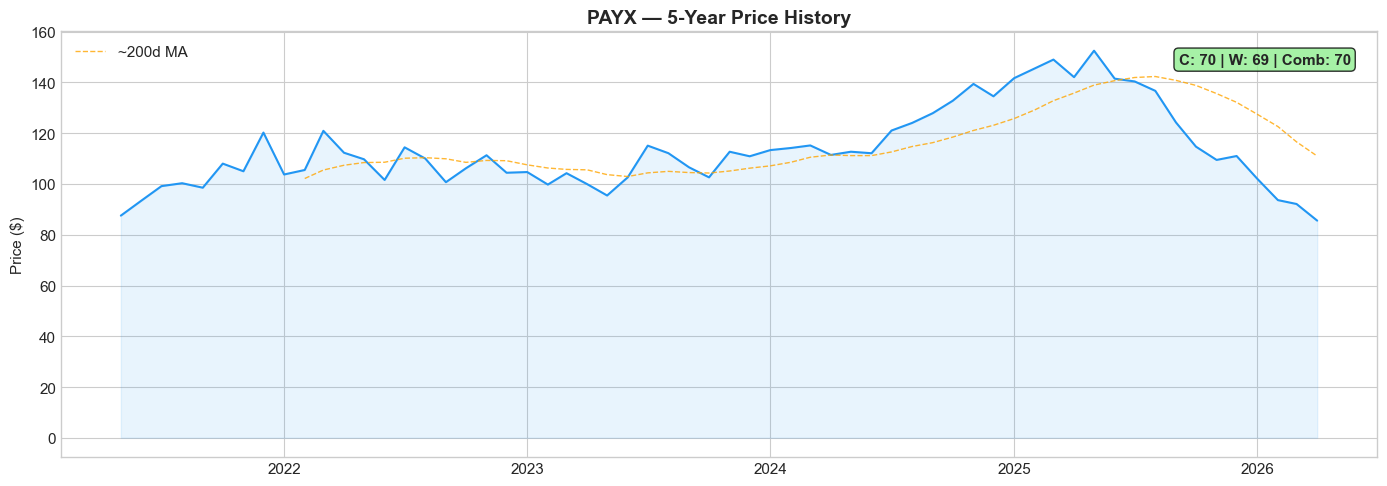


  DEEP DIVE: ADP — Automatic Data Processing, Inc.

📋 OVERVIEW
   Sector: Industrials | Sub-Industry: Human Resource & Employment Services
   Market Cap: $76.4B
   Business: Automatic Data Processing, Inc. provides cloud-based human capital management (HCM) solutions worldwide. It operates in two segments, Employer Services and Professional Employer Organization (PEO). Th...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Combs Score:    68.7/100  🏆
   🟢 Weschler Score: 66.6/100  
   🟢 Combined Score: 67.6/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🟡 Unit Economics:     16.7/25
     ★ Gross Margin:    46.0%   (

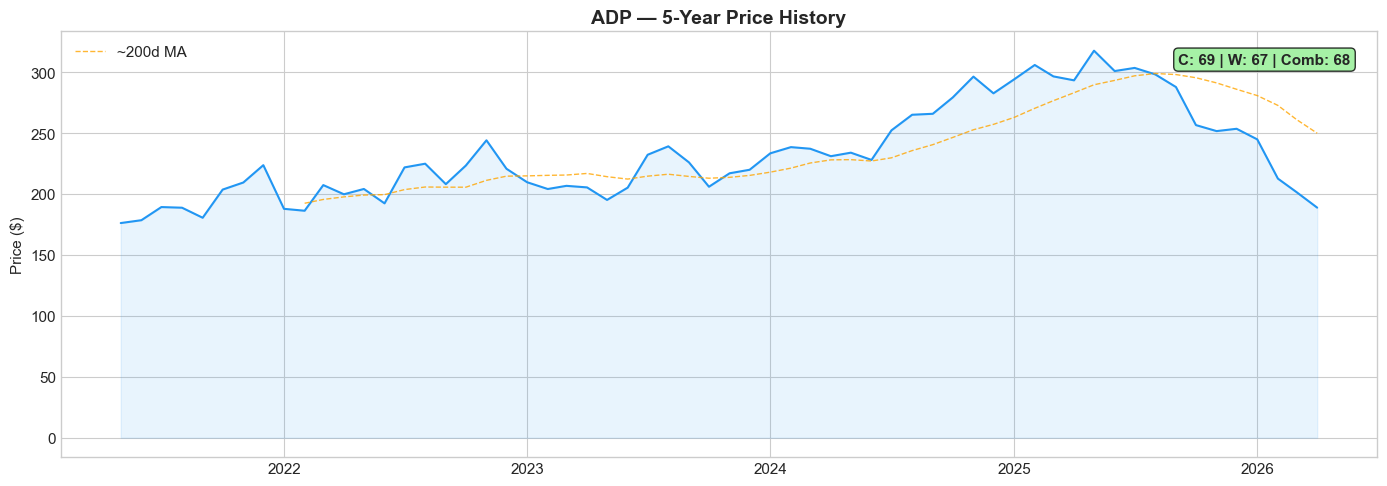


  DEEP DIVE: NTAP — NetApp, Inc.

📋 OVERVIEW
   Sector: Information Technology | Sub-Industry: Technology Hardware, Storage & Peripherals
   Market Cap: $19.0B
   Business: NetApp, Inc. provides a range of enterprise software, systems, and services that customers use to transform their data infrastructures in the United States, Canada, Latin America, Europe, the Middle E...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🟡 Combs Score:    64.0/100  🏆
   🟢 Weschler Score: 68.2/100  
   🟢 Combined Score: 66.1/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🟡 Unit Economics:     17.7/25
     ★ Gross Margin:    70.2%   (w

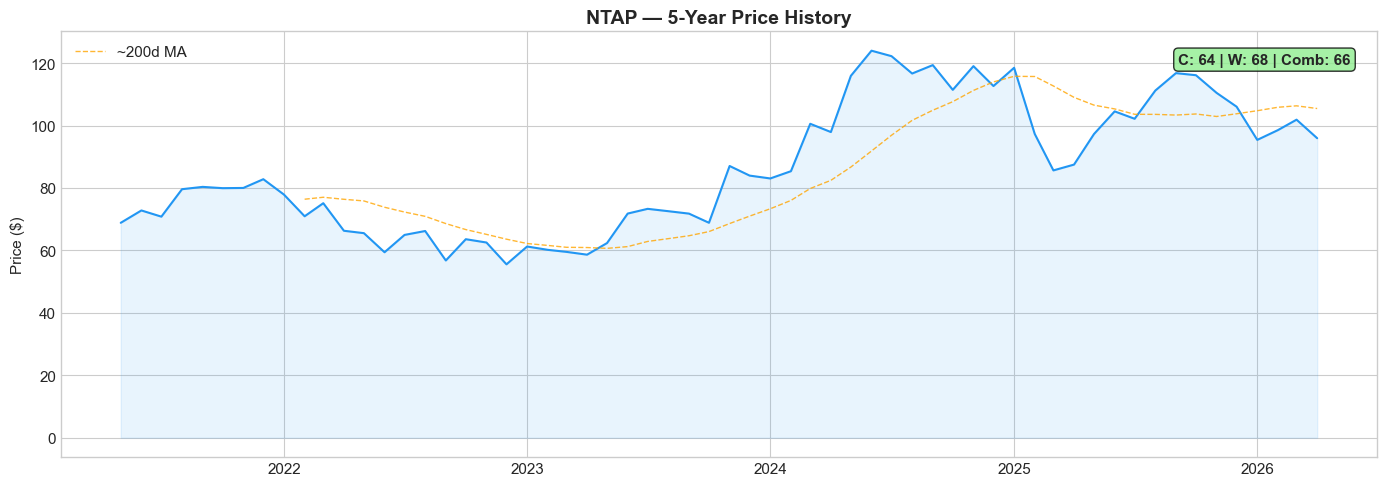


  DEEP DIVE: FICO — Fair Isaac Corporation

📋 OVERVIEW
   Sector: Information Technology | Sub-Industry: Application Software
   Market Cap: $21.9B
   Business: Fair Isaac Corporation provides analytics software in the Americas, Europe, the Middle East, Africa, and the Asia Pacific. It operates through two segments, Scores and Software. The Scores segment off...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Combs Score:    65.5/100  🏆
   🟢 Weschler Score: 65.2/100  
   🟢 Combined Score: 65.4/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Unit Economics:     20.8/25
     ★ Gross Margin:    82.2%   (wt: 30%)
    

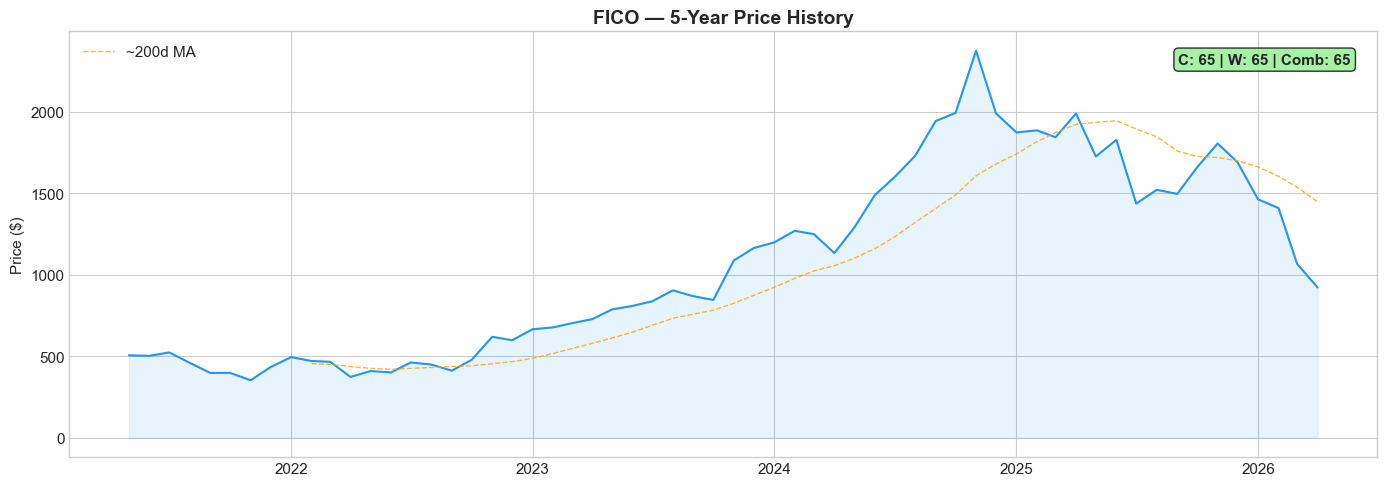


  DEEP DIVE: MO — Altria Group, Inc.

📋 OVERVIEW
   Sector: Consumer Staples | Sub-Industry: Tobacco
   Market Cap: $112.7B
   Business: Altria Group, Inc., through its subsidiaries, manufactures and sells smokeable and oral tobacco products in the United States. It offers cigarettes primarily under the Marlboro brand; large cigars and...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Combs Score:    65.3/100  🏆
   🟢 Weschler Score: 62.2/100  
   🟢 Combined Score: 63.8/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Unit Economics:     21.9/25
     ★ Gross Margin:    72.2%   (wt: 30%)
     ★ Op Margin:       59.8

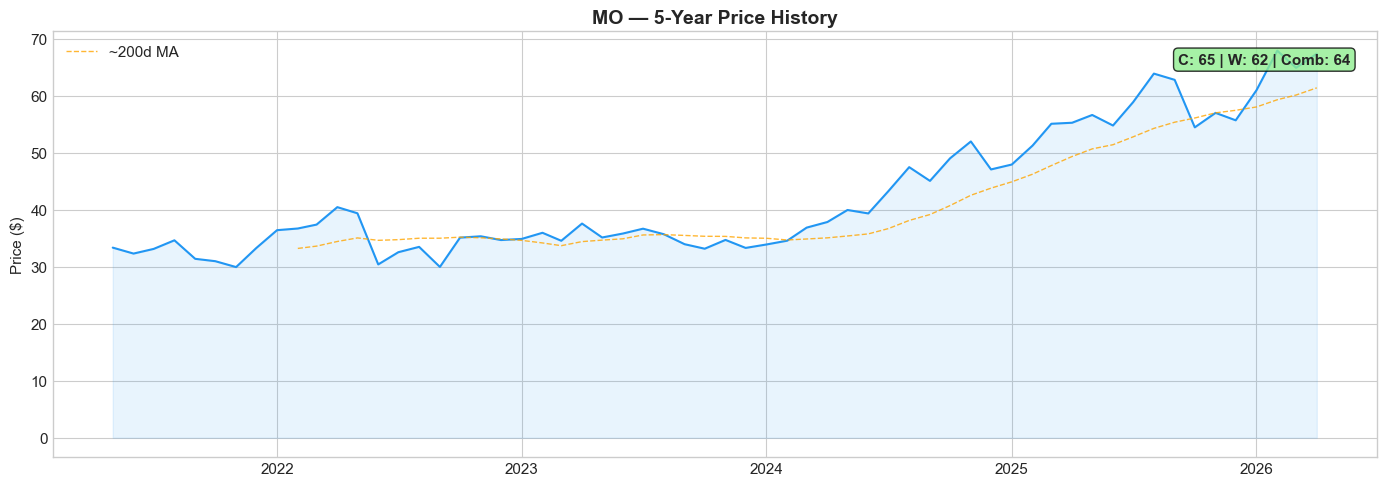


  DEEP DIVE: GDDY — GoDaddy Inc.

📋 OVERVIEW
   Sector: Information Technology | Sub-Industry: Internet Services & Infrastructure
   Market Cap: $10.7B
   Business: GoDaddy Inc. engages in the design and development of cloud-based products in the United States and internationally. It operates in two segments: Applications and Commerce (A&C), and Core Platform (Co...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🟡 Combs Score:    61.9/100  🏆
   🟢 Weschler Score: 64.0/100  
   🟢 Combined Score: 62.9/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🟡 Unit Economics:     15.4/25
     ★ Gross Margin:    63.6%   (wt: 30%)


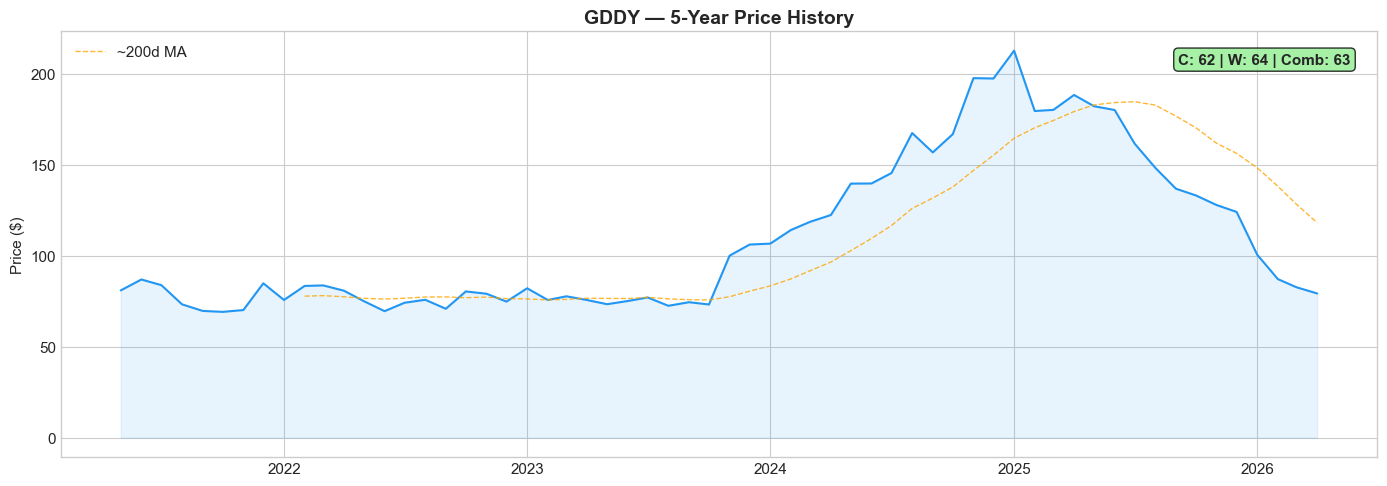


  DEEP DIVE: ACN — Accenture plc

📋 OVERVIEW
   Sector: Information Technology | Sub-Industry: IT Consulting & Other Services
   Market Cap: $110.5B
   Business: Accenture plc provides strategy and consulting, industry X, song, and technology and operation services in the Americas, Europe, the Middle East, Africa, and the Asia Pacific. It offers systems integr...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🟡 Combs Score:    60.4/100  
   🟢 Weschler Score: 65.3/100  🏆
   🟢 Combined Score: 62.8/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🔴 Unit Economics:     11.9/25
     ★ Gross Margin:    31.9%   (wt: 30%)
   

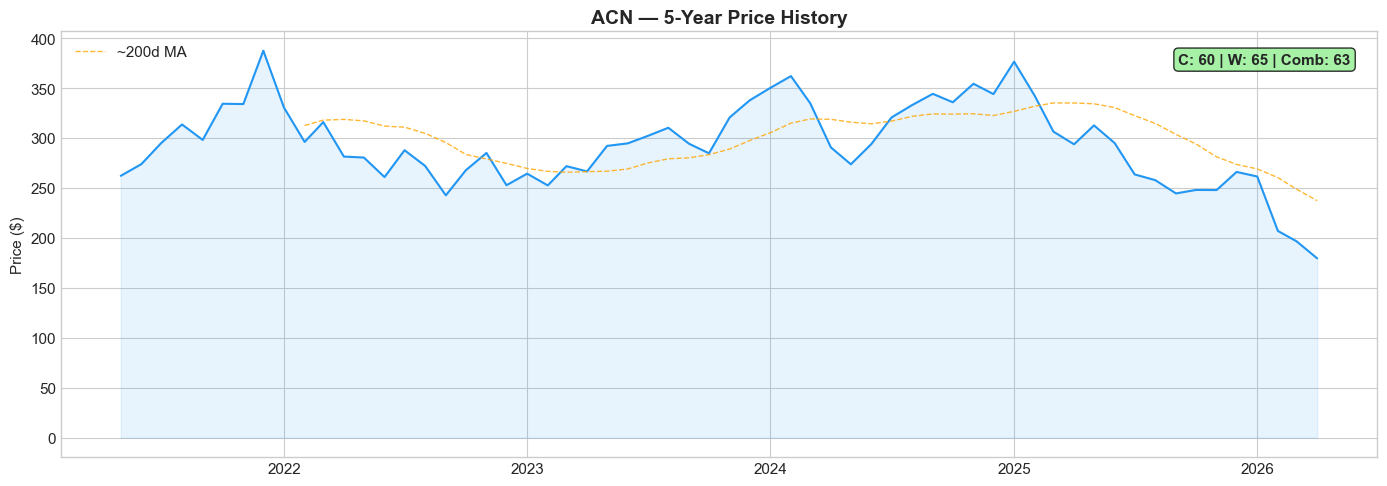


  DEEP DIVE: FDS — FactSet Research Systems Inc.

📋 OVERVIEW
   Sector: Financials | Sub-Industry: Financial Exchanges & Data
   Market Cap: $7.9B
   Business: FactSet Research Systems Inc., together with its subsidiaries, operates as a financial digital platform and enterprise solutions provider for the investment community. It offers data, products, and an...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🟡 Combs Score:    63.7/100  🏆
   🟢 Weschler Score: 61.3/100  
   🟢 Combined Score: 62.5/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🟢 Unit Economics:     18.9/25
     ★ Gross Margin:    52.7%   (wt: 30%)
     

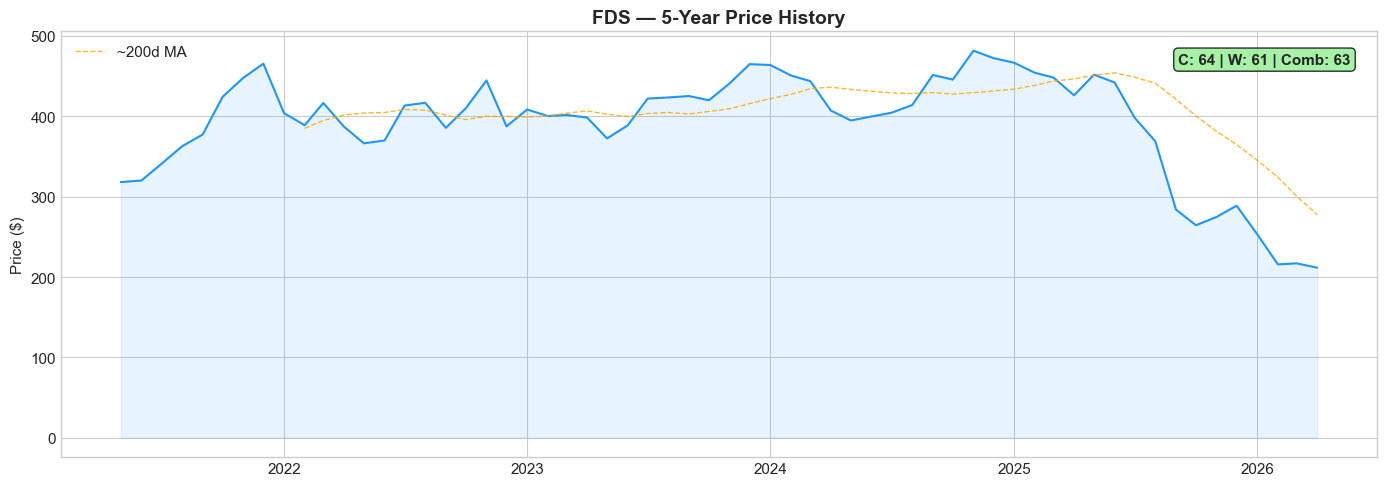


  DEEP DIVE: FFIV — F5, Inc.

📋 OVERVIEW
   Sector: Information Technology | Sub-Industry: Communications Equipment
   Market Cap: $16.5B
   Business: F5, Inc. provides multicloud application security and delivery solutions in the United States, Europe, the Middle East, Africa, and the Asia Pacific region. The company's distributed cloud services en...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🟡 Combs Score:    62.5/100  🏆
   🟢 Weschler Score: 61.0/100  
   🟢 Combined Score: 61.8/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🟡 Unit Economics:     17.8/25
     ★ Gross Margin:    81.4%   (wt: 30%)
     ★ Op Marg

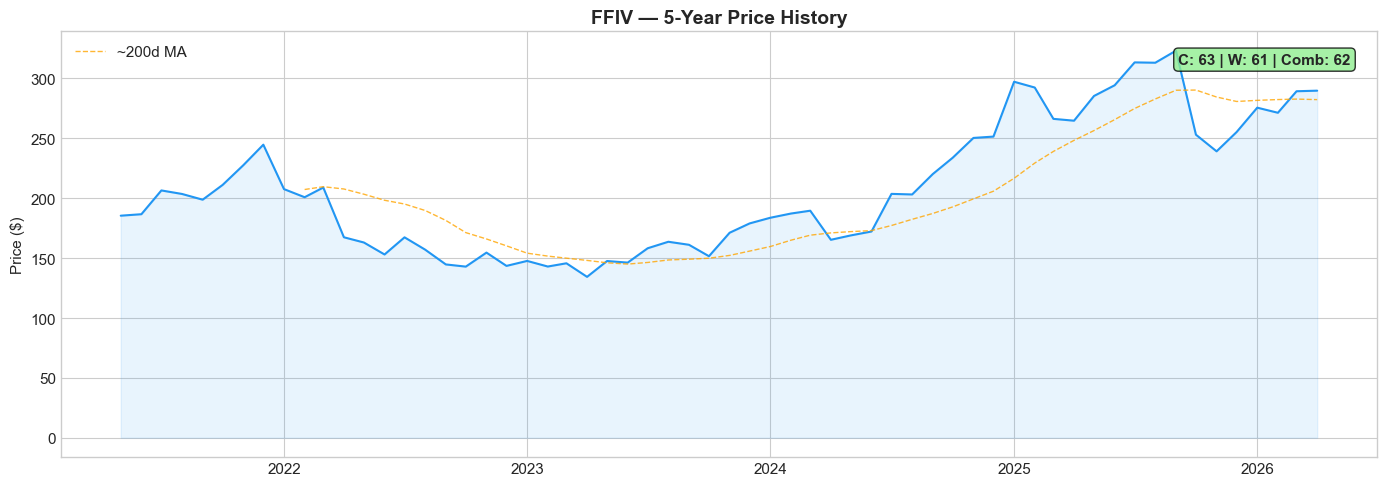


  DEEP DIVE: ALLE — Allegion plc

📋 OVERVIEW
   Sector: Industrials | Sub-Industry: Building Products
   Market Cap: $12.5B
   Business: Allegion plc engages in the provision of security products and solutions worldwide. It is operating through two segments: Allegion Americas and Allegion International. The company offers door controls...

─────────────────────────────────────────────────────────────────────────────────────
  📊 OVERALL SCORES
─────────────────────────────────────────────────────────────────────────────────────
   🟡 Combs Score:    60.7/100  
   🟢 Weschler Score: 60.9/100  
   🟢 Combined Score: 60.8/100

─────────────────────────────────────────────────────────────────────────────────────
  🎯 COMBS BREAKDOWN — "Is this a great business?"
  (★ = highest-weighted metric in sub-score)
─────────────────────────────────────────────────────────────────────────────────────
   🟡 Unit Economics:     15.0/25
     ★ Gross Margin:    45.2%   (wt: 30%)
     ★ Op Margin:       21.1%

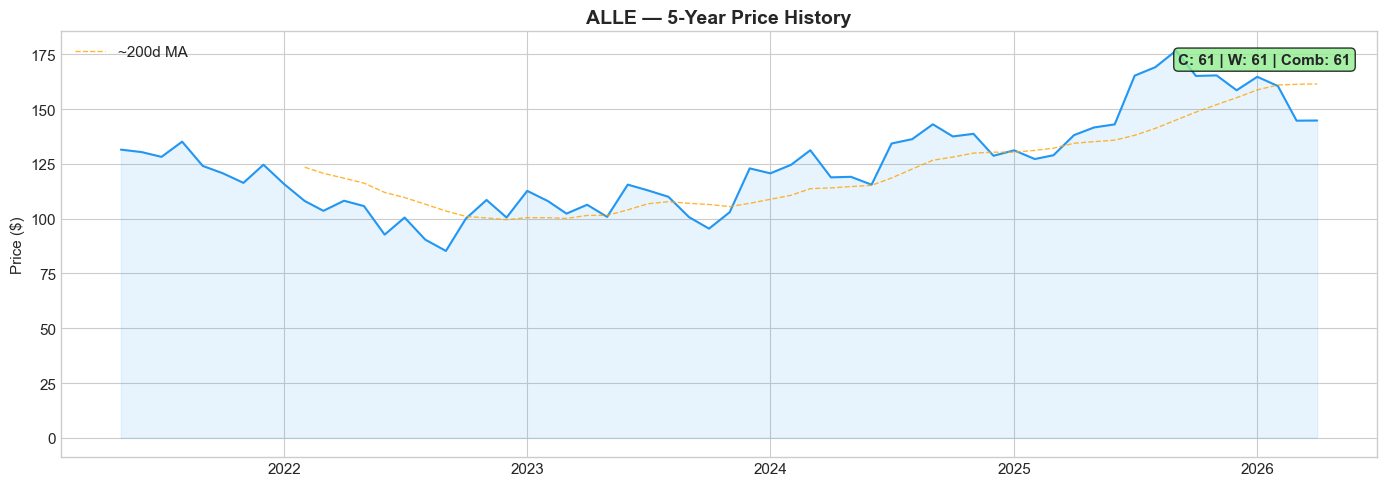

(company                                                         Paychex, Inc.
 sector                                                            Industrials
 market_cap                                                        30658951168
 description                 Paychex, Inc., together with its subsidiaries,...
 trailing_pe                                                         18.889624
 forward_pe                                                          14.497689
 peg_ratio                                                                 NaN
 price_to_book                                                        7.638815
 price_to_sales                                                        7.72655
 beta                                                                      NaN
 dividend_yield                                                           4.92
 short_percent                                                          0.0652
 analyst_count                                      

In [13]:
deep_dive("PAYX"), deep_dive("ADP"), deep_dive("NTAP"), deep_dive("FICO"), deep_dive("MO"), deep_dive("GDDY"), deep_dive("ACN"), deep_dive("FDS"), deep_dive("FFIV"), deep_dive("ALLE")